In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from posydon.popsyn.synthetic_population import Rates
from posydon.popsyn.rate_calculation import get_shell_comoving_volume
import cmap

In [2]:
tol_vibrant = cmap.Colormap('tol:vibrant')(np.linspace(0, 1, 7))


In [3]:
import h5py
# load spline
spline_file = '/home/users/b/briel/scratch/high_mass_physics/data/spline_data/ppd_pdfs_mean_m1qzchieff_mmin40_collector_only_10000w_10000s_rng129_zspline.h5'

file = h5py.File(spline_file, 'r')

In [4]:
file.close()

In [5]:
for color in tol_vibrant:
    print(color)

[0.         0.46666667 0.73333333 1.        ]
[0.2        0.73333333 0.93333333 1.        ]
[0.         0.6        0.53333333 1.        ]
[0.93333333 0.46666667 0.2        1.        ]
[0.8        0.2        0.06666667 1.        ]
[0.93333333 0.2        0.46666667 1.        ]
[0.73333333 0.73333333 0.73333333 1.        ]


Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max
Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max
Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max


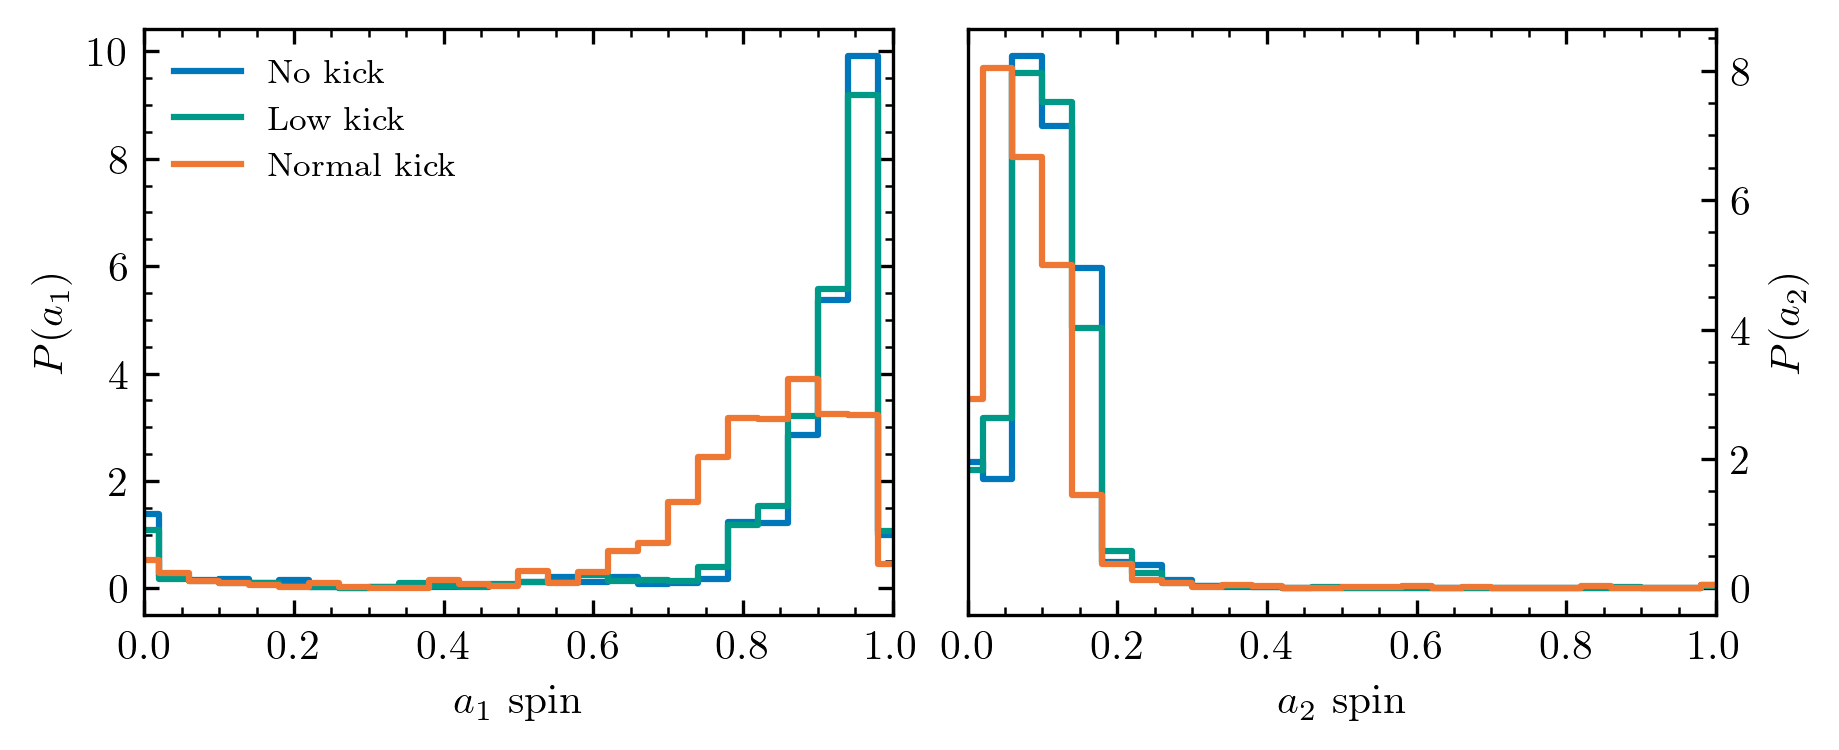

In [177]:
# individual spins and tilts
data_dir = '/home/users/b/briel/scratch/high_mass_physics/data/figure_2/'
folder_types = ['no_kick', 'low_kick', 'normal_kick']
colors = [tol_vibrant[0], tol_vibrant[2], tol_vibrant[3]]
labels = ['No kick', 'Low kick', 'Normal kick']

fig, ax = plt.subplots(1, 2, figsize=(3.38*2, 2.535))
plt.subplots_adjust(wspace=0.1)


for folder_type, color, label in zip(folder_types, colors, labels):
    folder_path = os.path.join(data_dir, folder_type)
    co_contact_file = os.path.join(folder_path, 'CO_contact.h5')
    data = Rates(co_contact_file, 'BBH', 'IllustrisTNG')
    
    spin_bins = np.linspace(-0.1, 1.1, 31)
    x = np.linspace(0, 1, 200)
    z_max = 2
    z_mask = data.z_events <= z_max
    volume = get_shell_comoving_volume(0, z_max)
    
    max_array = np.maximum(data.population['S1_mass'],
                                data.population['S2_mass'])
    
    mass_mask = (max_array > 40.0)
    
    total_rate = np.sum(data.weights[z_mask], axis=1)
    total_rate = total_rate.to_numpy().sum()/volume

    reverse_mask = data.population['S1_mass'] < data.population['S2_mass']
    S1_spin_temp = data.population['S1_spin'].copy()
    S1_spin_temp[reverse_mask] = data.population['S2_spin'][reverse_mask]
    S2_spin_temp = data.population['S2_spin'].copy()
    S2_spin_temp[reverse_mask] = data.population['S1_spin'][reverse_mask]

    h, _ = np.histogram(S1_spin_temp[mass_mask], 
                        bins=spin_bins,
                        weights=np.sum(data.weights[z_mask], axis=1)[mass_mask],
                        density=True)

    ax[0].step(spin_bins[:-1], h, label=label, where='post',
               color=color)

    h, _ = np.histogram(S2_spin_temp[mass_mask],
                        bins=spin_bins,
                        weights=np.sum(data.weights[z_mask], axis=1)[mass_mask],
                        density=True)
    ax[1].step(spin_bins[:-1], h, where='post',
                color=color)

    ax[0].set_xlabel('$a_1$ spin')
    ax[0].set_ylabel(r'$P(a_1)$')
    ax[1].set_xlabel('$a_2$ spin')


    ax[1].yaxis.set_label_position("right")
    ax[1].yaxis.tick_right()
    ax[1].set_ylabel(r'$P(a_2)$')

    ax[0].legend()
    ax[0].set_xlim(0,1)
    ax[1].set_xlim(0,1)


In [82]:
data.population.columns

Index(['time', 'metallicity', 'S1_mass', 'S2_mass', 'S1_spin', 'S2_spin',
       'S1_state', 'S2_state', 'S1_spin_orbit_tilt', 'S2_spin_orbit_tilt',
       'chirp_mass', 'mass_ratio', 'chi_eff', 'channel'],
      dtype='object')

Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max
Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max
Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max


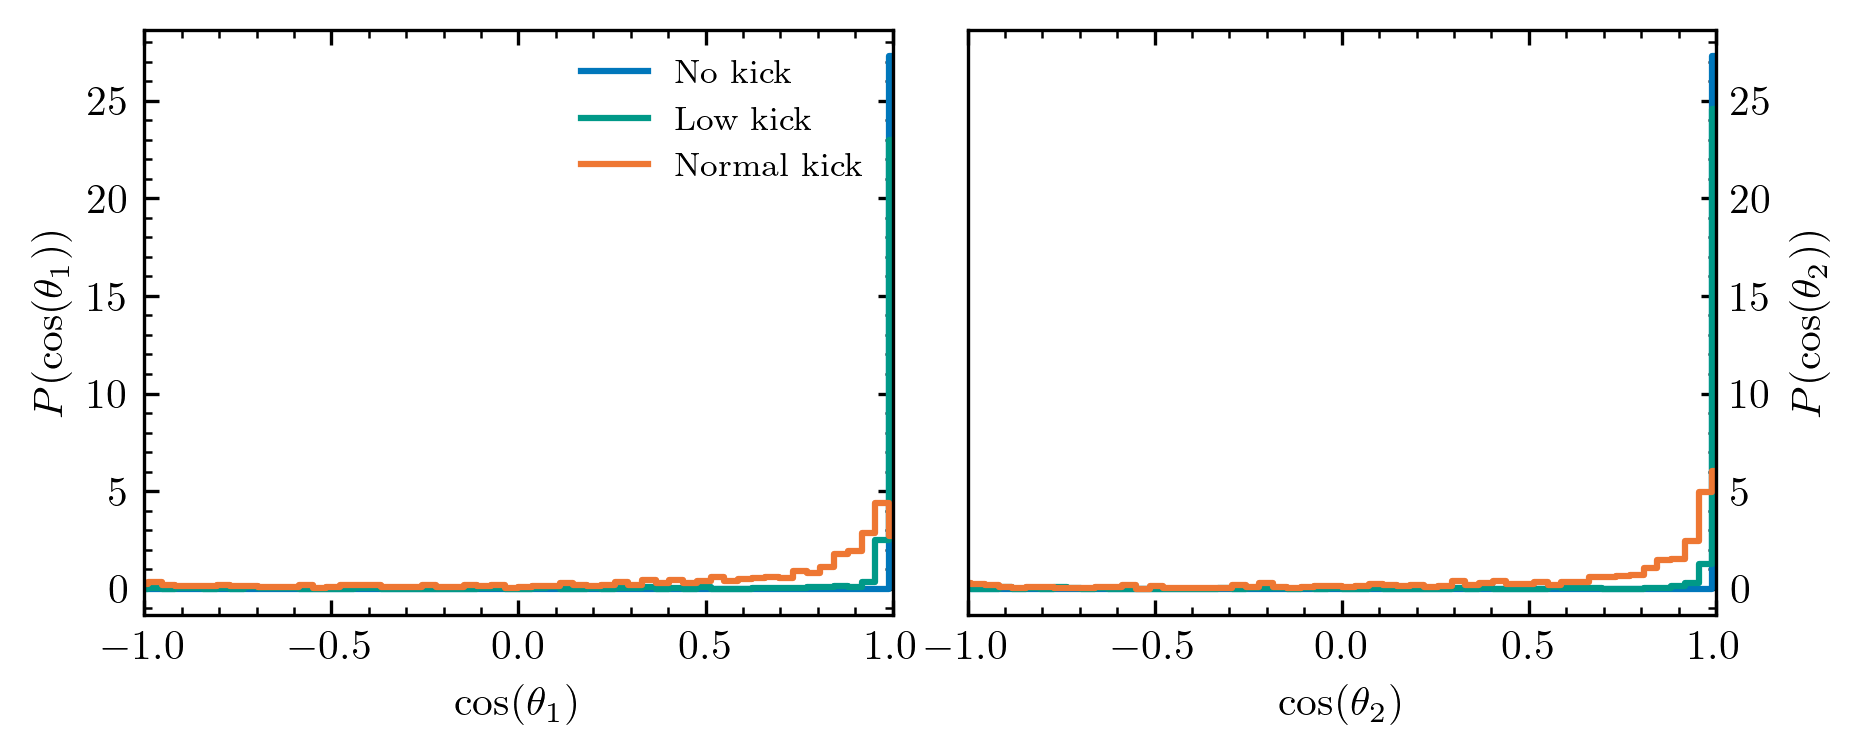

In [108]:
# individual spins and tilts
data_dir = '/home/users/b/briel/scratch/high_mass_physics/data/figure_2/'
folder_types = ['no_kick', 'low_kick', 'normal_kick']
colors = [tol_vibrant[0], tol_vibrant[2], tol_vibrant[3]]
labels = ['No kick', 'Low kick', 'Normal kick']

fig, ax = plt.subplots(1, 2, figsize=(3.38*2, 2.535))
plt.subplots_adjust(wspace=0.1)

spin_bins = np.linspace(-1.1, 1.1, 61)

for folder_type, color, label in zip(folder_types, colors, labels):
    folder_path = os.path.join(data_dir, folder_type)
    co_contact_file = os.path.join(folder_path, 'CO_contact.h5')
    data = Rates(co_contact_file, 'BBH', 'IllustrisTNG')

    z_max = 2
    z_mask = data.z_events <= z_max
    volume = get_shell_comoving_volume(0, z_max)
    total_rate = np.sum(data.weights[z_mask], axis=1)
    total_rate = total_rate.to_numpy().sum()/volume
    
    max_array = np.maximum(data.population['S1_mass'],
                                data.population['S2_mass'])
    mass_mask = max_array > 40

    reverse_mask = data.population['S1_mass'] < data.population['S2_mass']
    S1_spin_temp = data.population['S1_spin_orbit_tilt'].copy()
    S1_spin_temp[reverse_mask] = data.population['S2_spin_orbit_tilt'][reverse_mask]
    S2_spin_temp = data.population['S2_spin_orbit_tilt'].copy()
    S2_spin_temp[reverse_mask] = data.population['S1_spin_orbit_tilt'][reverse_mask]

    h, _ = np.histogram(np.cos(S1_spin_temp)[mass_mask], 
                        bins=spin_bins,
                        weights=np.sum(data.weights[z_mask], axis=1)[mass_mask],density=True)

    ax[0].step(spin_bins[:-1], h, label=label, where='post',
               color=color)

    h, _ = np.histogram(np.cos(S2_spin_temp)[mass_mask],
                        bins=spin_bins,
                        weights=np.sum(data.weights[z_mask], axis=1)[mass_mask],density=True)

    ax[1].step(spin_bins[:-1], h, where='post',
                color=color)
    

    ax[0].set_xlabel(r'$\cos(\theta_1)$')
    ax[0].set_ylabel(r'$P(\cos(\theta_1))$')
    ax[1].set_xlabel(r'$\cos(\theta_2)$')

    ax[1].yaxis.set_label_position("right")
    ax[1].yaxis.tick_right()
    ax[1].set_ylabel(r'$P(\cos(\theta_2))$')

    ax[0].legend()
    ax[0].set_xlim(-1,1)
    ax[1].set_xlim(-1,1)

In [192]:
def chi_eff(theta_1, theta_2, a1, a2, m1, m2):
    
    nominator = m1*a1*np.cos(theta_1) + m2*a2*np.cos(theta_2)
    chi_eff = nominator / (m1 + m2)
    return chi_eff

def precession(theta_1, theta_2, a1, a2, m1, m2):
    """Calculate the effective spin precession.
    
    Following the formulation in Gerosa+2021, which 
    is used in LIGO/Virgo analyses.
    
    Parameters
    ----------
    theta_1 : float or np.ndarray
        Tilt angle of the primary spin (in radians).
    theta_2 : float or np.ndarray
        Tilt angle of the secondary spin (in radians).
    a1 : float or np.ndarray
        Dimensionless spin magnitude of the primary.
    a2 : float or np.ndarray
        Dimensionless spin magnitude of the secondary.
    m1 : float or np.ndarray
        Mass of the primary.
    m2 : float or np.ndarray
        Mass of the secondary.
    """
    q = m2/m1
    a_1_perp = np.abs(a1 * np.sin(theta_1))
    a_2_perp = q * ((4*q + 3)/(4+3*q)) * a2 * np.sin(theta_2)
    chi_p = np.maximum(a_1_perp, a_2_perp)
    return chi_p

Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max
Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max
Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max


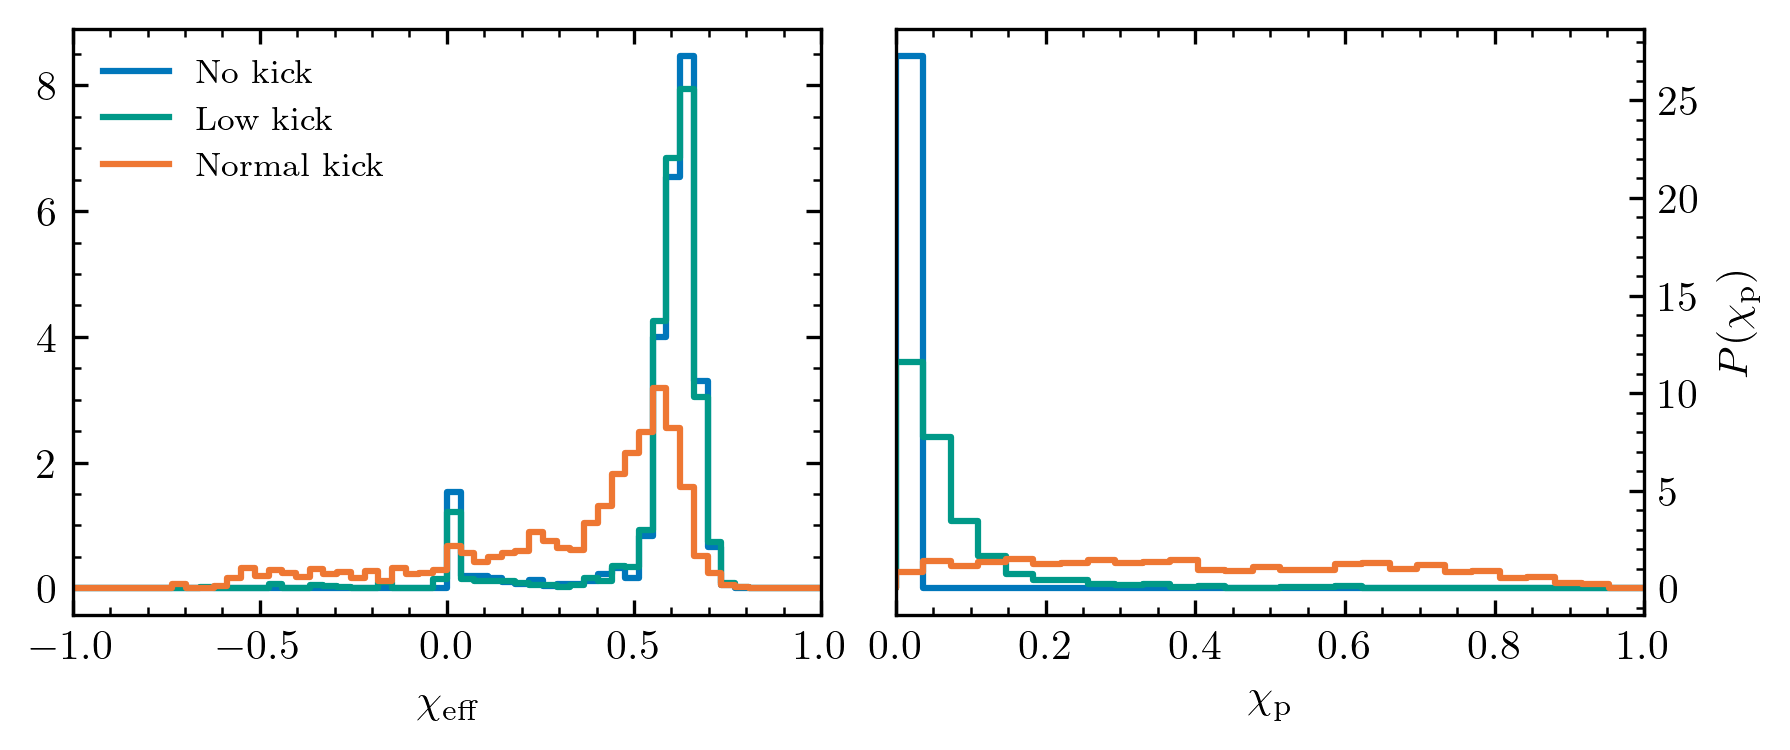

In [174]:
# individual spins and tilts
data_dir = '/home/users/b/briel/scratch/high_mass_physics/data/figure_2/'
folder_types = ['no_kick', 'low_kick', 'normal_kick']
colors = [tol_vibrant[0], tol_vibrant[2], tol_vibrant[3]]
labels = ['No kick', 'Low kick', 'Normal kick']

fig, ax = plt.subplots(1, 2, figsize=(3.38*2, 2.535))
plt.subplots_adjust(wspace=0.1)

bins = np.linspace(-1.1, 1.1, 61)

for folder_type, color, label in zip(folder_types, colors, labels):
    folder_path = os.path.join(data_dir, folder_type)
    co_contact_file = os.path.join(folder_path, 'CO_contact.h5')
    data = Rates(co_contact_file, 'BBH', 'IllustrisTNG')

    z_max = 2
    z_mask = data.z_events <= z_max
    volume = get_shell_comoving_volume(0, z_max)
    total_rate = np.sum(data.weights[z_mask], axis=1)
    total_rate = total_rate.to_numpy().sum()/volume
    
    max_array = np.maximum(data.population['S1_mass'],
                                data.population['S2_mass'])
    mass_mask = max_array > 40


    reverse_mask = data.population['S1_mass'] < data.population['S2_mass']

    S1_max = data.population['S1_mass'].copy()
    S1_max[reverse_mask] = data.population['S2_mass'][reverse_mask]
    S2_min = data.population['S2_mass'].copy()
    S2_min[reverse_mask] = data.population['S1_mass'][reverse_mask]
    S1_spin_tilt_max = data.population['S1_spin_orbit_tilt'].copy()
    S1_spin_tilt_max[reverse_mask] = data.population['S2_spin_orbit_tilt'][reverse_mask]
    S2_spin_tilt_min = data.population['S2_spin_orbit_tilt'].copy()
    S2_spin_tilt_min[reverse_mask] = data.population['S1_spin_orbit_tilt'][reverse_mask]
    S1_spin_max = data.population['S1_spin'].copy()
    S1_spin_max[reverse_mask] = data.population['S2_spin'][reverse_mask]
    S2_spin_min = data.population['S2_spin'].copy()
    S2_spin_min[reverse_mask] = data.population['S1_spin'][reverse_mask]
    
    
    
    chi_eff_array  = chi_eff(S1_spin_tilt_max,
                        S2_spin_tilt_min,
                        S1_spin_max,
                        S2_spin_min,
                        S1_max,
                        S2_min)

    h, _ = np.histogram(chi_eff_array[mass_mask], 
                        bins=bins,
                        weights=np.sum(data.weights[z_mask], axis=1)[mass_mask],density=True)

    ax[0].step(bins[:-1], h, label=label, where='post',
               color=color)
    
    chi_p = precession(S1_spin_tilt_max, 
                       S2_spin_tilt_min,
                       S1_spin_max,
                       S2_spin_min,
                       S1_max,
                       S2_min)

    h, _ = np.histogram(chi_p[mass_mask],
                        bins=bins,
                        weights=np.sum(data.weights[z_mask], axis=1)[mass_mask],density=True)

    ax[1].step(bins[:-1], h, where='post',
                color=color)
    

    ax[0].set_xlabel(r'$\chi_\mathrm{eff}$')
    #ax[0].set_ylabel(r'$P(\cos(\theta_1))$')
    ax[1].set_xlabel(r'$\chi_\mathrm{p}$')

    ax[1].yaxis.set_label_position("right")
    ax[1].yaxis.tick_right()
    ax[1].set_ylabel(r'$P(\chi_\mathrm{p})$')

    ax[0].legend()
    ax[0].set_xlim(-1,1)
    ax[1].set_xlim(0,1)

Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max
Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max
Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max


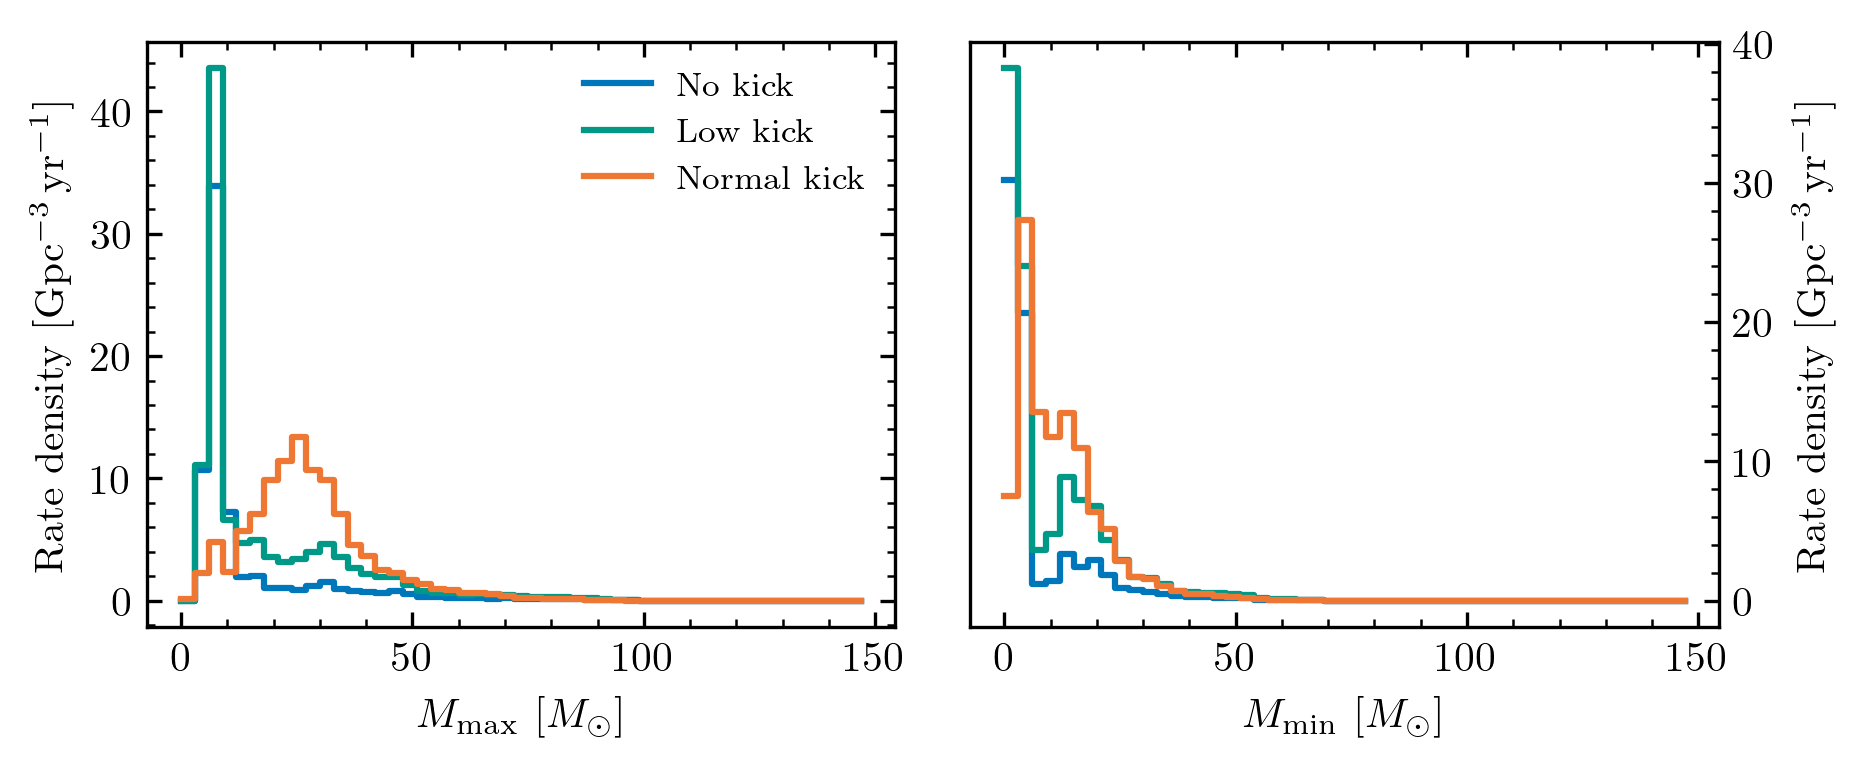

In [ ]:
# individual spins and tilts
data_dir = '/home/users/b/briel/scratch/high_mass_physics/data/figure_2/'
folder_types = ['no_kick', 'low_kick', 'normal_kick']
colors = [tol_vibrant[0], tol_vibrant[2], tol_vibrant[3]]
labels = ['No kick', 'Low kick', 'Normal kick']

fig, ax = plt.subplots(1, 2, figsize=(3.38*2, 2.535))
plt.subplots_adjust(wspace=0.1)
bins = np.linspace(0,150,51)

for folder_type, color, label in zip(folder_types, colors, labels):
    folder_path = os.path.join(data_dir, folder_type)
    co_contact_file = os.path.join(folder_path, 'CO_contact.h5')
    data = Rates(co_contact_file, 'BBH', 'IllustrisTNG')
    
    spin_bins = np.linspace(-0.1, 1.1, 31)
    x = np.linspace(0, 1, 200)
    z_max = 2
    z_mask = data.z_events <= z_max
    volume = get_shell_comoving_volume(0, z_max)
    total_rate = np.sum(data.weights[z_mask], axis=1)
    total_rate = total_rate.to_numpy().sum()/volume

    reverse_mask = data.population['S1_mass'] < data.population['S2_mass']
    S1_mass_tmp = data.population['S1_mass'].copy()
    S1_mass_tmp[reverse_mask] = data.population['S2_mass'][reverse_mask]
    S2_mass_tmp = data.population['S2_mass'].copy()
    S2_mass_tmp[reverse_mask] = data.population['S1_mass'][reverse_mask]

    h, _ = np.histogram(S1_mass_tmp, 
                        bins=bins,
                        weights=np.sum(data.weights[z_mask], axis=1))
    h /= (np.diff(bins)*volume)

    ax[0].step(bins[:-1], h, label=label, where='post',
               color=color)

    h, _ = np.histogram(S2_mass_tmp,
                        bins=bins,
                        weights=np.sum(data.weights[z_mask], axis=1))
    h /=( np.diff(bins)*volume)

    ax[1].step(bins[:-1], h, where='post',
                color=color)

    ax[0].set_xlabel('$M_\mathrm{max}$ [$M_\odot$]')
    ax[0].set_ylabel(r'Rate density $\mathrm{[Gpc^{-3}\,yr^{-1}]}$')
    ax[1].set_xlabel('$M_\mathrm{min}$ [$M_\odot$]')


    ax[1].yaxis.set_label_position("right")
    ax[1].yaxis.tick_right()
    ax[1].set_ylabel(r'Rate density $\mathrm{[Gpc^{-3}\,yr^{-1}]}$')

    ax[0].legend()
    #ax[0].set_xlim(0,1)
    #ax[1].set_xlim(0,1)
    #ax[0].set_ylim(0,2500)
    #ax[1].set_ylim(0,2500)


Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max
Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max
Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max


(0.0, 5.332990661136814)

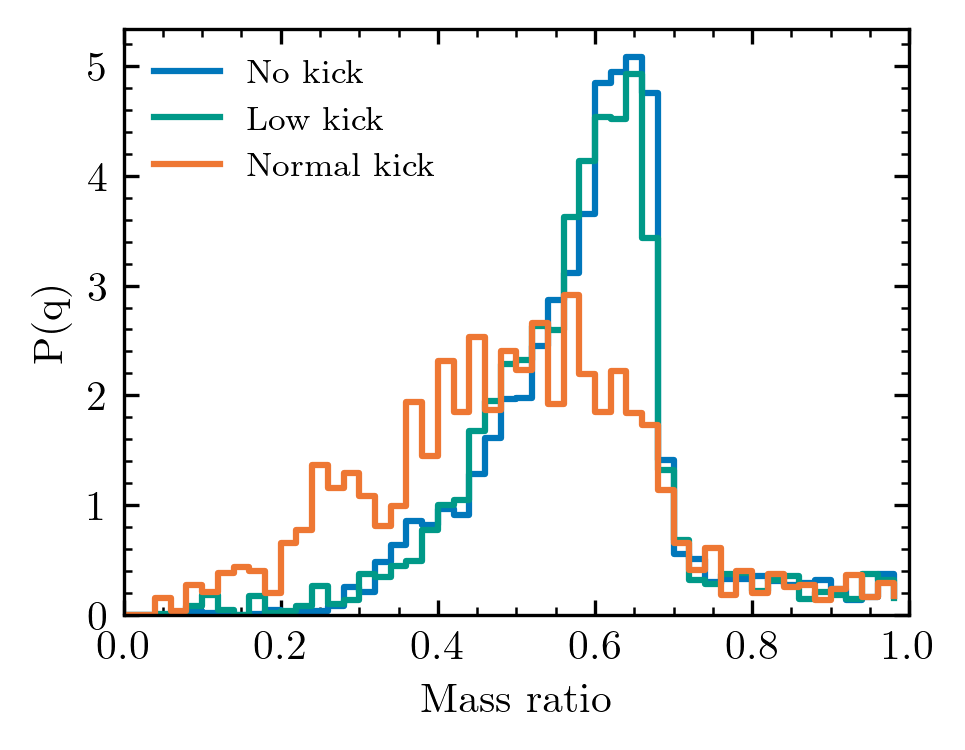

In [182]:
# individual spins and tilts
data_dir = '/home/users/b/briel/scratch/high_mass_physics/data/figure_2/'
folder_types = ['no_kick', 'low_kick', 'normal_kick']
colors = [tol_vibrant[0], tol_vibrant[2], tol_vibrant[3]]
labels = ['No kick', 'Low kick', 'Normal kick']

fig, ax = plt.subplots(1, 1, figsize=(3.38, 2.535))
plt.subplots_adjust(wspace=0.1)
bins = np.linspace(0,1,51)

for folder_type, color, label in zip(folder_types, colors, labels):
    folder_path = os.path.join(data_dir, folder_type)
    co_contact_file = os.path.join(folder_path, 'CO_contact.h5')
    data = Rates(co_contact_file, 'BBH', 'IllustrisTNG')
    
    x = np.linspace(0, 1, 200)
    z_max = 2
    z_mask = data.z_events <= z_max
    max_mass = np.maximum(data.population['S1_mass'],
                                data.population['S2_mass'])
    mass_mask = max_mass > 40
    
    volume = get_shell_comoving_volume(0, z_max)
    total_rate = np.sum(data.weights[z_mask], axis=1)   
    total_rate = total_rate.to_numpy().sum()/volume

    mass_ratio = data.population['mass_ratio']
    
    h, _ = np.histogram(mass_ratio[mass_mask], 
                        bins=bins,
                        weights=np.sum(data.weights[z_mask], axis=1)[mass_mask],density=True)
    
    ax.step(bins[:-1], h, label=label, where='post',
               color=color)

    ax.set_xlabel('Mass ratio')
    ax.set_ylabel(r'P(q)')

    ax.legend()

    ax.set_xlim(0,1)
    
ax.set_ylim(0)

# GRMHD

Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max
Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max
Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max


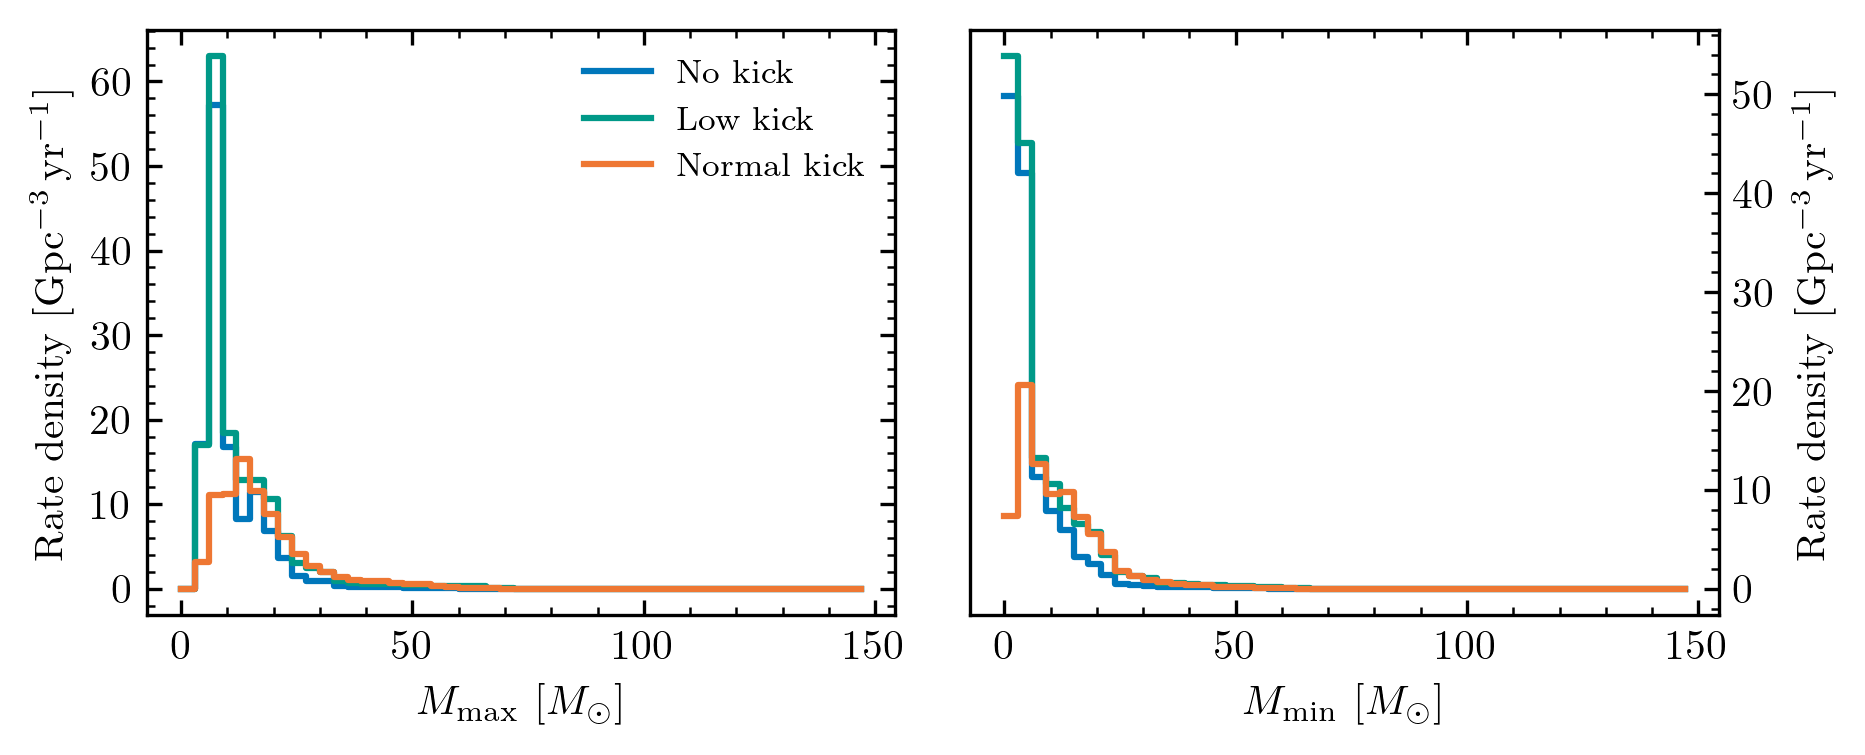

In [81]:
other_data_folder = "/srv/astro/projects/posydon/max/population_synthesis/250910_BH_kick_with_H"

# models with Eddington-limited accretion and different BH kick prescriptions
folder_types = ["/srv/astro/projects/posydon/max/population_synthesis/250708_SMT_focus/IF/run_20",
                "/srv/astro/projects/posydon/max/population_synthesis/250910_BH_kick_with_H/IF/run_05",
                "/srv/astro/projects/posydon/max/population_synthesis/250910_BH_kick_with_H/IF/run_03"]

# individual spins and tilts
colors = [tol_vibrant[0], tol_vibrant[2], tol_vibrant[3]]
labels = ['No kick', 'Low kick', 'Normal kick']

fig, ax = plt.subplots(1, 2, figsize=(3.38*2, 2.535))
plt.subplots_adjust(wspace=0.1)
bins = np.linspace(0,150,51)

for folder_path, color, label in zip(folder_types, colors, labels):
    co_contact_file = os.path.join(folder_path, 'CO_contact.h5')
    data = Rates(co_contact_file, 'BBH', 'IllustrisTNG')
    
    spin_bins = np.linspace(-0.1, 1.1, 31)
    x = np.linspace(0, 1, 200)
    z_max = 2
    z_mask = data.z_events <= z_max
    volume = get_shell_comoving_volume(0, z_max)
    total_rate = np.sum(data.weights[z_mask], axis=1)
    total_rate = total_rate.to_numpy().sum()/volume

    reverse_mask = data.population['S1_mass'] < data.population['S2_mass']
    S1_mass_tmp = data.population['S1_mass'].copy()
    S1_mass_tmp[reverse_mask] = data.population['S2_mass'][reverse_mask]
    S2_mass_tmp = data.population['S2_mass'].copy()
    S2_mass_tmp[reverse_mask] = data.population['S1_mass'][reverse_mask]

    h, _ = np.histogram(S1_mass_tmp, 
                        bins=bins,
                        weights=np.sum(data.weights[z_mask], axis=1))
    h /= (np.diff(bins)*volume)

    ax[0].step(bins[:-1], h, label=label, where='post',
               color=color)

    h, _ = np.histogram(S2_mass_tmp,
                        bins=bins,
                        weights=np.sum(data.weights[z_mask], axis=1))
    h /=( np.diff(bins)*volume)

    ax[1].step(bins[:-1], h, where='post',
                color=color)

    ax[0].set_xlabel('$M_\mathrm{max}$ [$M_\odot$]')
    ax[0].set_ylabel(r'Rate density $\mathrm{[Gpc^{-3}\,yr^{-1}]}$')
    ax[1].set_xlabel('$M_\mathrm{min}$ [$M_\odot$]')

    ax[1].yaxis.set_label_position("right")
    ax[1].yaxis.tick_right()
    ax[1].set_ylabel(r'Rate density $\mathrm{[Gpc^{-3}\,yr^{-1}]}$')

    ax[0].legend()
    #ax[0].set_xlim(0,1)
    #ax[1].set_xlim(0,1)
    #ax[0].set_ylim(0,2500)
    #ax[1].set_ylim(0,2500)


# GRMHD

Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max
Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max
Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max


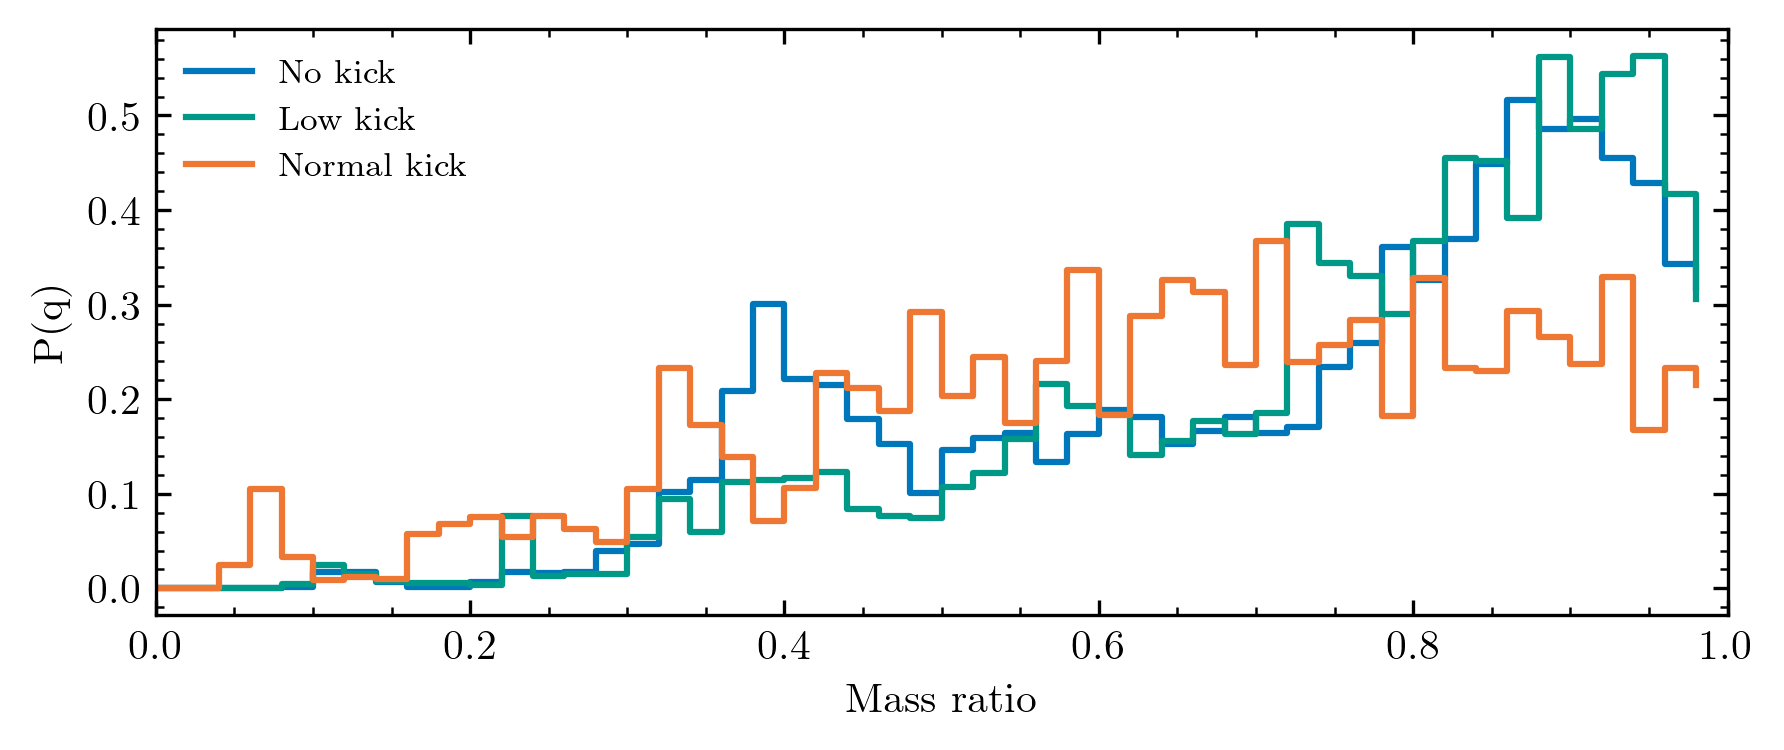

In [194]:
other_data_folder = "/srv/astro/projects/posydon/max/population_synthesis/250910_BH_kick_with_H"

# models with Eddington-limited accretion and different BH kick prescriptions
folder_types = ["/srv/astro/projects/posydon/max/population_synthesis/250825_high_mass/IF/run_04",
                "/srv/astro/projects/posydon/max/population_synthesis/250910_BH_kick_with_H/IF/run_04",
                "/srv/astro/projects/posydon/max/population_synthesis/250910_BH_kick_with_H/IF/run_02"]

# individual spins and tilts
colors = [tol_vibrant[0], tol_vibrant[2], tol_vibrant[3]]
labels = ['No kick', 'Low kick', 'Normal kick']

fig, ax = plt.subplots(1, 1, figsize=(3.38*2, 2.535))
plt.subplots_adjust(wspace=0.1)
bins = np.linspace(0, 1, 51)

for folder_path, color, label in zip(folder_types, colors, labels):
    co_contact_file = os.path.join(folder_path, 'CO_contact.h5')
    data = Rates(co_contact_file, 'BBH', 'IllustrisTNG')
    
    x = np.linspace(0, 1, 200)
    z_max = 2
    z_mask = data.z_events <= z_max
    max_mass = np.maximum(data.population['S1_mass'],
                                data.population['S2_mass'])
    mass_mask = max_mass > 40
    
    volume = get_shell_comoving_volume(0, z_max)
    total_rate = np.sum(data.weights[z_mask], axis=1)   
    total_rate = total_rate.to_numpy().sum()/volume

    mass_ratio = data.population['mass_ratio']
    
    h, _ = np.histogram(mass_ratio[mass_mask], 
                        bins=bins,
                        weights=np.sum(data.weights[z_mask], axis=1)[mass_mask], density=True)
    h /= (np.diff(bins)*volume)
    
    ax.step(bins[:-1], h, label=label, where='post',
               color=color)

    ax.set_xlabel('Mass ratio')
    ax.set_ylabel('P(q)')

    ax.legend()

    ax.set_xlim(0,1)

Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max
Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max
Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max


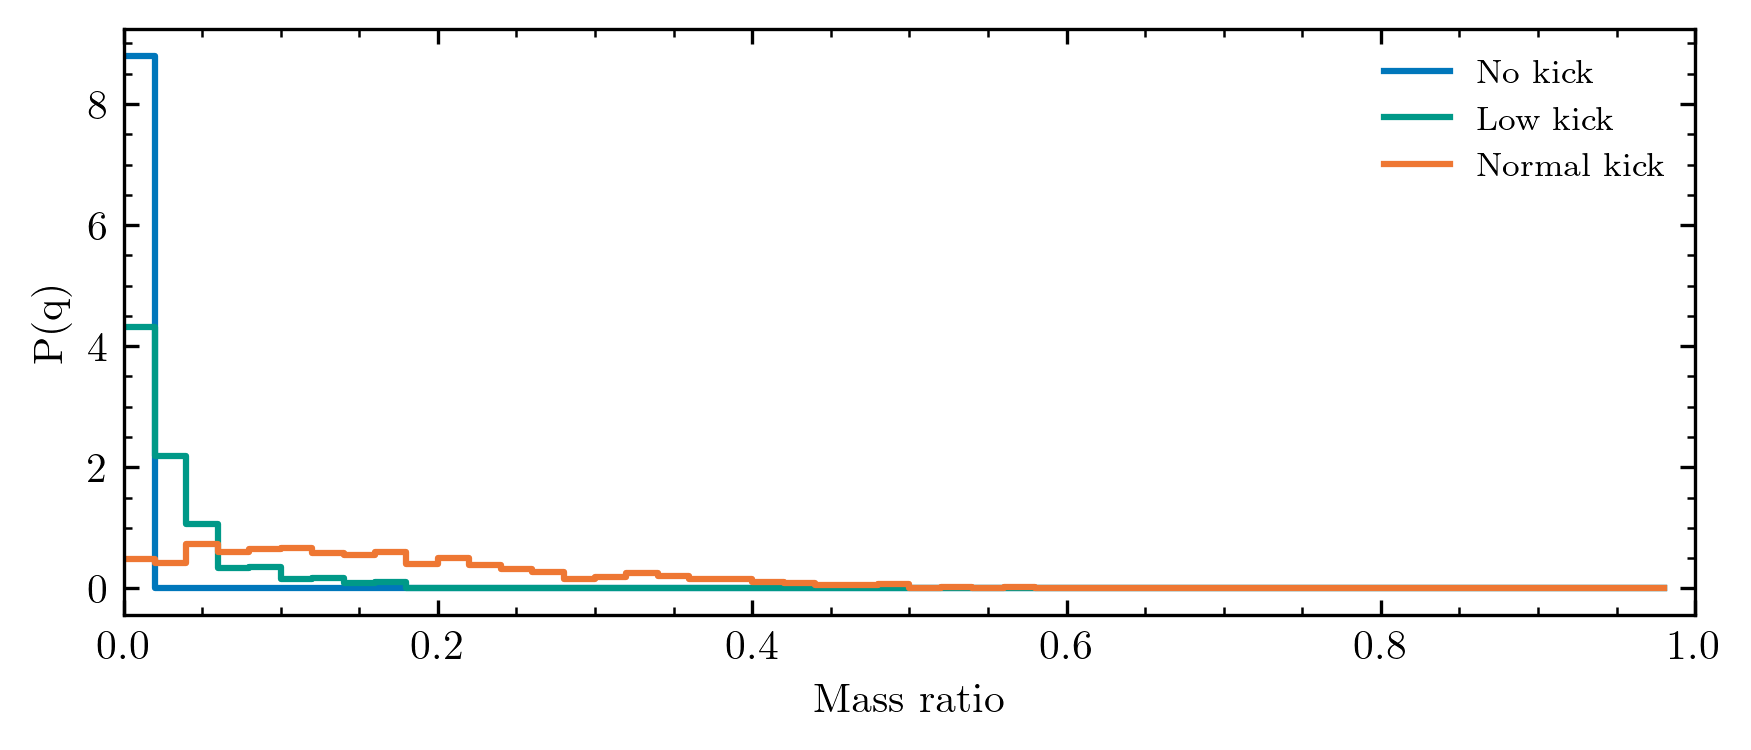

In [195]:
other_data_folder = "/srv/astro/projects/posydon/max/population_synthesis/250910_BH_kick_with_H"

# models with Eddington-limited accretion and different BH kick prescriptions
folder_types = ["/srv/astro/projects/posydon/max/population_synthesis/250825_high_mass/IF/run_04",
                "/srv/astro/projects/posydon/max/population_synthesis/250910_BH_kick_with_H/IF/run_04",
                "/srv/astro/projects/posydon/max/population_synthesis/250910_BH_kick_with_H/IF/run_02"]

# individual spins and tilts
colors = [tol_vibrant[0], tol_vibrant[2], tol_vibrant[3]]
labels = ['No kick', 'Low kick', 'Normal kick']

fig, ax = plt.subplots(1, 1, figsize=(3.38*2, 2.535))
plt.subplots_adjust(wspace=0.1)
bins = np.linspace(0, 1, 51)

for folder_path, color, label in zip(folder_types, colors, labels):
    co_contact_file = os.path.join(folder_path, 'CO_contact.h5')
    data = Rates(co_contact_file, 'BBH', 'IllustrisTNG')
    
    x = np.linspace(0, 1, 200)
    z_max = 2
    z_mask = data.z_events <= z_max
    max_mass = np.maximum(data.population['S1_mass'],
                                data.population['S2_mass'])
    mass_mask = max_mass > 40
    
    volume = get_shell_comoving_volume(0, z_max)
    total_rate = np.sum(data.weights[z_mask], axis=1)   
    total_rate = total_rate.to_numpy().sum()/volume
    reverse_mask = data.population['S1_mass'] < data.population['S2_mass']
    S1_mass_tmp = data.population['S1_mass'].copy()
    S1_mass_tmp[reverse_mask] = data.population['S2_mass'][reverse_mask]
    S2_mass_tmp = data.population['S2_mass'].copy()
    S2_mass_tmp[reverse_mask] = data.population['S1_mass'][reverse_mask]
    S1_spin_tmp = data.population['S1_spin'].copy()
    S1_spin_tmp[reverse_mask] = data.population['S2_spin'][reverse_mask]
    S2_spin_tmp = data.population['S2_spin'].copy()
    S2_spin_tmp[reverse_mask] = data.population['S1_spin'][reverse_mask]
    S1_spin_tilt_tmp = data.population['S1_spin_orbit_tilt'].copy()
    S1_spin_tilt_tmp[reverse_mask] = data.population['S2_spin_orbit_tilt'][reverse_mask]
    S2_spin_tilt_tmp = data.population['S2_spin_orbit_tilt'].copy()
    S2_spin_tilt_tmp[reverse_mask] = data.population['S1_spin_orbit_tilt'][reverse_mask]

    mass_ratio = precession(S1_spin_tilt_tmp,
                            S2_spin_tilt_tmp,
                            S1_spin_tmp,
                            S2_spin_tmp,
                            S1_mass_tmp,
                            S2_mass_tmp)

    h, _ = np.histogram(mass_ratio[mass_mask],
                        bins=bins,
                        weights=np.sum(data.weights[z_mask], axis=1)[mass_mask], density=True)
    h /= (np.diff(bins)*volume)
    
    ax.step(bins[:-1], h, label=label, where='post',
               color=color)

    ax.set_xlabel('Mass ratio')
    ax.set_ylabel('P(q)')

    ax.legend()

    ax.set_xlim(0,1)

Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max
Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max
Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max


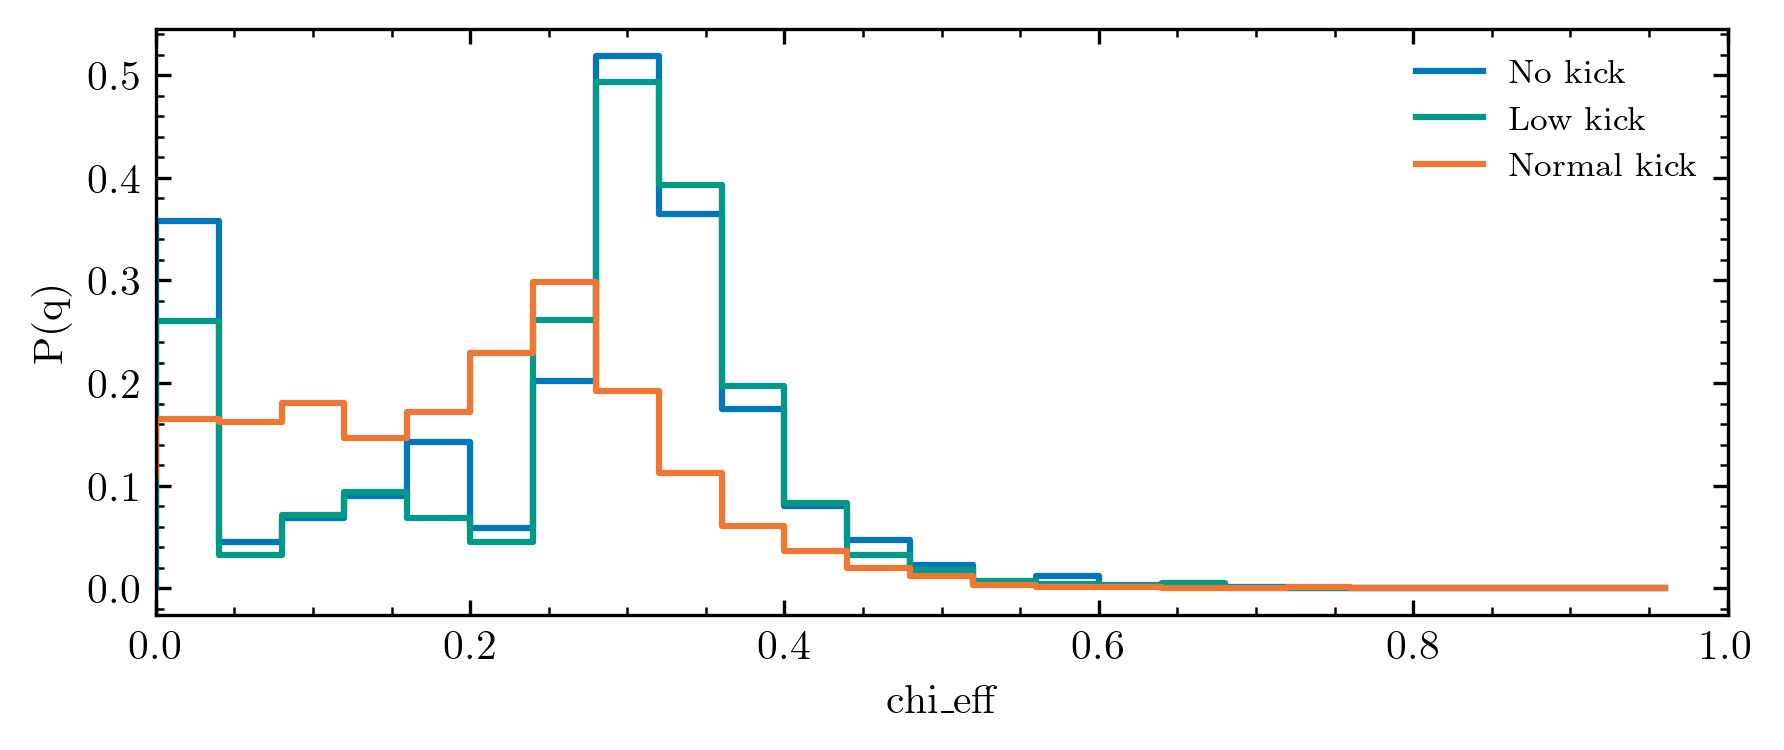

In [196]:
other_data_folder = "/srv/astro/projects/posydon/max/population_synthesis/250910_BH_kick_with_H"

# models with Eddington-limited accretion and different BH kick prescriptions
folder_types = ["/srv/astro/projects/posydon/max/population_synthesis/250825_high_mass/IF/run_04",
                "/srv/astro/projects/posydon/max/population_synthesis/250910_BH_kick_with_H/IF/run_04",
                "/srv/astro/projects/posydon/max/population_synthesis/250910_BH_kick_with_H/IF/run_02"]

# individual spins and tilts
colors = [tol_vibrant[0], tol_vibrant[2], tol_vibrant[3]]
labels = ['No kick', 'Low kick', 'Normal kick']

fig, ax = plt.subplots(1, 1, figsize=(3.38*2, 2.535))
plt.subplots_adjust(wspace=0.1)
bins = np.linspace(-1, 1, 51)

for folder_path, color, label in zip(folder_types, colors, labels):
    co_contact_file = os.path.join(folder_path, 'CO_contact.h5')
    data = Rates(co_contact_file, 'BBH', 'IllustrisTNG')
    
    z_max = 2
    z_mask = data.z_events <= z_max
    max_mass = np.maximum(data.population['S1_mass'],
                                data.population['S2_mass'])
    mass_mask = max_mass > 40
    
    volume = get_shell_comoving_volume(0, z_max)
    total_rate = np.sum(data.weights[z_mask], axis=1)   
    total_rate = total_rate.to_numpy().sum()/volume
    reverse_mask = data.population['S1_mass'] < data.population['S2_mass']
    S1_mass_tmp = data.population['S1_mass'].copy()
    S1_mass_tmp[reverse_mask] = data.population['S2_mass'][reverse_mask]
    S2_mass_tmp = data.population['S2_mass'].copy()
    S2_mass_tmp[reverse_mask] = data.population['S1_mass'][reverse_mask]
    S1_spin_tmp = data.population['S1_spin'].copy()
    S1_spin_tmp[reverse_mask] = data.population['S2_spin'][reverse_mask]
    S2_spin_tmp = data.population['S2_spin'].copy()
    S2_spin_tmp[reverse_mask] = data.population['S1_spin'][reverse_mask]
    S1_spin_tilt_tmp = data.population['S1_spin_orbit_tilt'].copy()
    S1_spin_tilt_tmp[reverse_mask] = data.population['S2_spin_orbit_tilt'][reverse_mask]
    S2_spin_tilt_tmp = data.population['S2_spin_orbit_tilt'].copy()
    S2_spin_tilt_tmp[reverse_mask] = data.population['S1_spin_orbit_tilt'][reverse_mask]

    mass_ratio = chi_eff(S1_spin_tilt_tmp,
                            S2_spin_tilt_tmp,
                            S1_spin_tmp,
                            S2_spin_tmp,
                            S1_mass_tmp,
                            S2_mass_tmp)

    h, _ = np.histogram(mass_ratio[mass_mask],
                        bins=bins,
                        weights=np.sum(data.weights[z_mask], axis=1)[mass_mask], density=True)
    h /= (np.diff(bins)*volume)
    
    ax.step(bins[:-1], h, label=label, where='post',
               color=color)

    ax.set_xlabel('chi_eff')
    ax.set_ylabel('P(q)')

    ax.legend()

    ax.set_xlim(0,1)

Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max
Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max
Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max


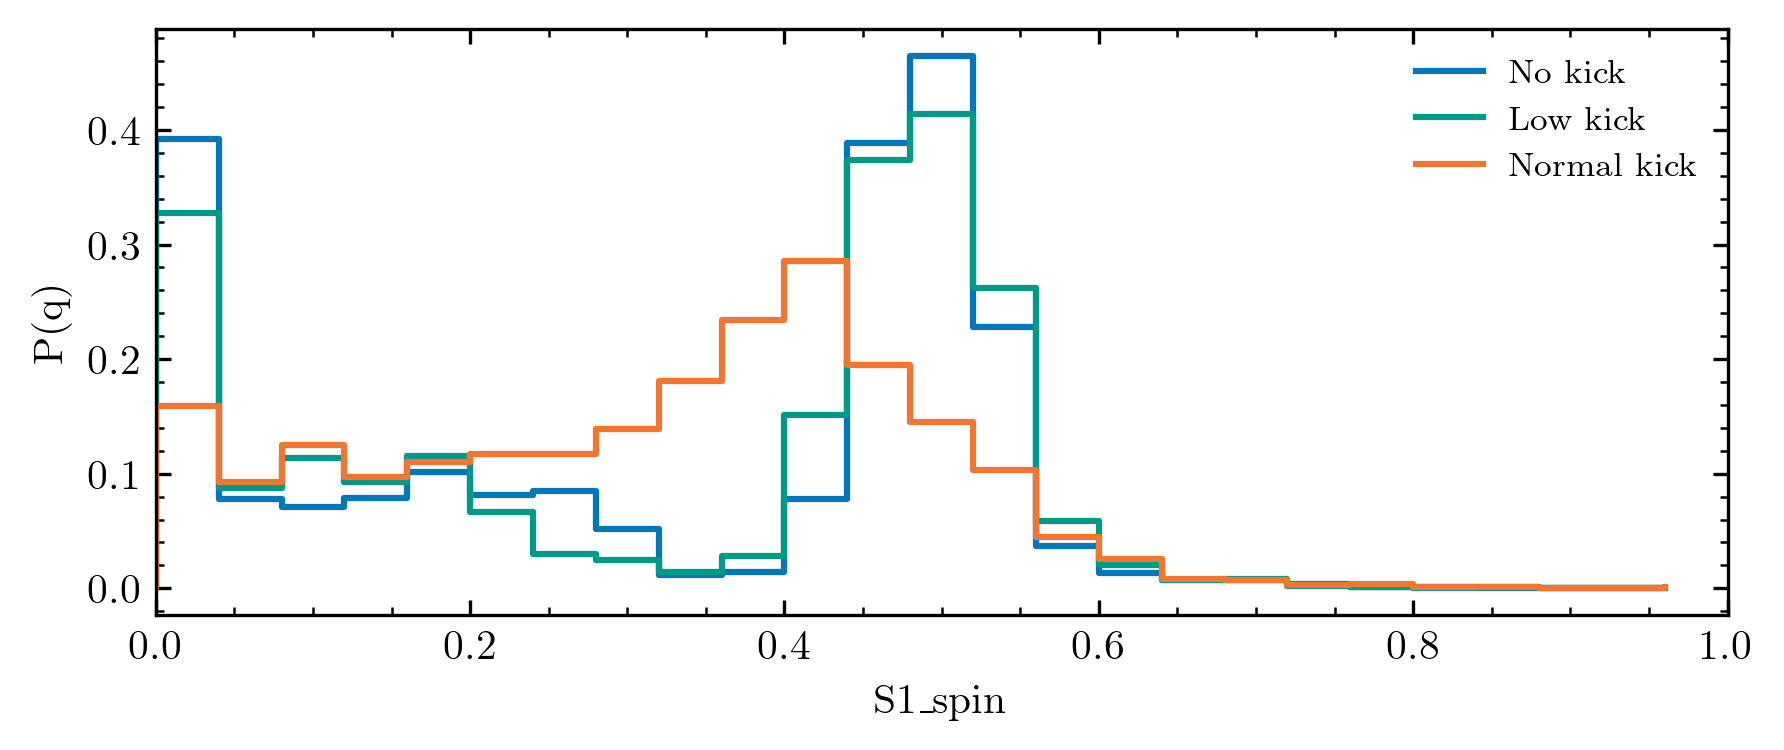

In [198]:
other_data_folder = "/srv/astro/projects/posydon/max/population_synthesis/250910_BH_kick_with_H"

# models with Eddington-limited accretion and different BH kick prescriptions
folder_types = ["/srv/astro/projects/posydon/max/population_synthesis/250825_high_mass/IF/run_04",
                "/srv/astro/projects/posydon/max/population_synthesis/250910_BH_kick_with_H/IF/run_04",
                "/srv/astro/projects/posydon/max/population_synthesis/250910_BH_kick_with_H/IF/run_02"]

# individual spins and tilts
colors = [tol_vibrant[0], tol_vibrant[2], tol_vibrant[3]]
labels = ['No kick', 'Low kick', 'Normal kick']

fig, ax = plt.subplots(1, 1, figsize=(3.38*2, 2.535))
plt.subplots_adjust(wspace=0.1)
bins = np.linspace(-1, 1, 51)

for folder_path, color, label in zip(folder_types, colors, labels):
    co_contact_file = os.path.join(folder_path, 'CO_contact.h5')
    data = Rates(co_contact_file, 'BBH', 'IllustrisTNG')
    
    z_max = 2
    z_mask = data.z_events <= z_max
    max_mass = np.maximum(data.population['S1_mass'],
                                data.population['S2_mass'])
    mass_mask = max_mass > 40
    
    volume = get_shell_comoving_volume(0, z_max)
    total_rate = np.sum(data.weights[z_mask], axis=1)   
    total_rate = total_rate.to_numpy().sum()/volume
    reverse_mask = data.population['S1_mass'] < data.population['S2_mass']
    S1_mass_tmp = data.population['S1_mass'].copy()
    S1_mass_tmp[reverse_mask] = data.population['S2_mass'][reverse_mask]
    S2_mass_tmp = data.population['S2_mass'].copy()
    S2_mass_tmp[reverse_mask] = data.population['S1_mass'][reverse_mask]
    S1_spin_tmp = data.population['S1_spin'].copy()
    S1_spin_tmp[reverse_mask] = data.population['S2_spin'][reverse_mask]
    S2_spin_tmp = data.population['S2_spin'].copy()
    S2_spin_tmp[reverse_mask] = data.population['S1_spin'][reverse_mask]
    S1_spin_tilt_tmp = data.population['S1_spin_orbit_tilt'].copy()
    S1_spin_tilt_tmp[reverse_mask] = data.population['S2_spin_orbit_tilt'][reverse_mask]
    S2_spin_tilt_tmp = data.population['S2_spin_orbit_tilt'].copy()
    S2_spin_tilt_tmp[reverse_mask] = data.population['S1_spin_orbit_tilt'][reverse_mask]

    mass_ratio = S1_spin_tmp

    h, _ = np.histogram(mass_ratio[mass_mask],
                        bins=bins,
                        weights=np.sum(data.weights[z_mask], axis=1)[mass_mask], density=True)
    h /= (np.diff(bins)*volume)
    
    ax.step(bins[:-1], h, label=label, where='post',
               color=color)

    ax.set_xlabel('S1_spin')
    ax.set_ylabel('P(q)')

    ax.legend()

    ax.set_xlim(0,1)
    

## Delay Time for Three Accretion Populations

Processing folder: Eddington-limited
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max
  Total systems: 4124
  Total rate: 4.16e+00 yr^-1
Processing folder: GRMHD
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max
  Total systems: 5062
  Total rate: 5.18e+00 yr^-1
Processing folder: conservative
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max
  Total systems: 9010
  Total rate: 1.37e+01 yr^-1


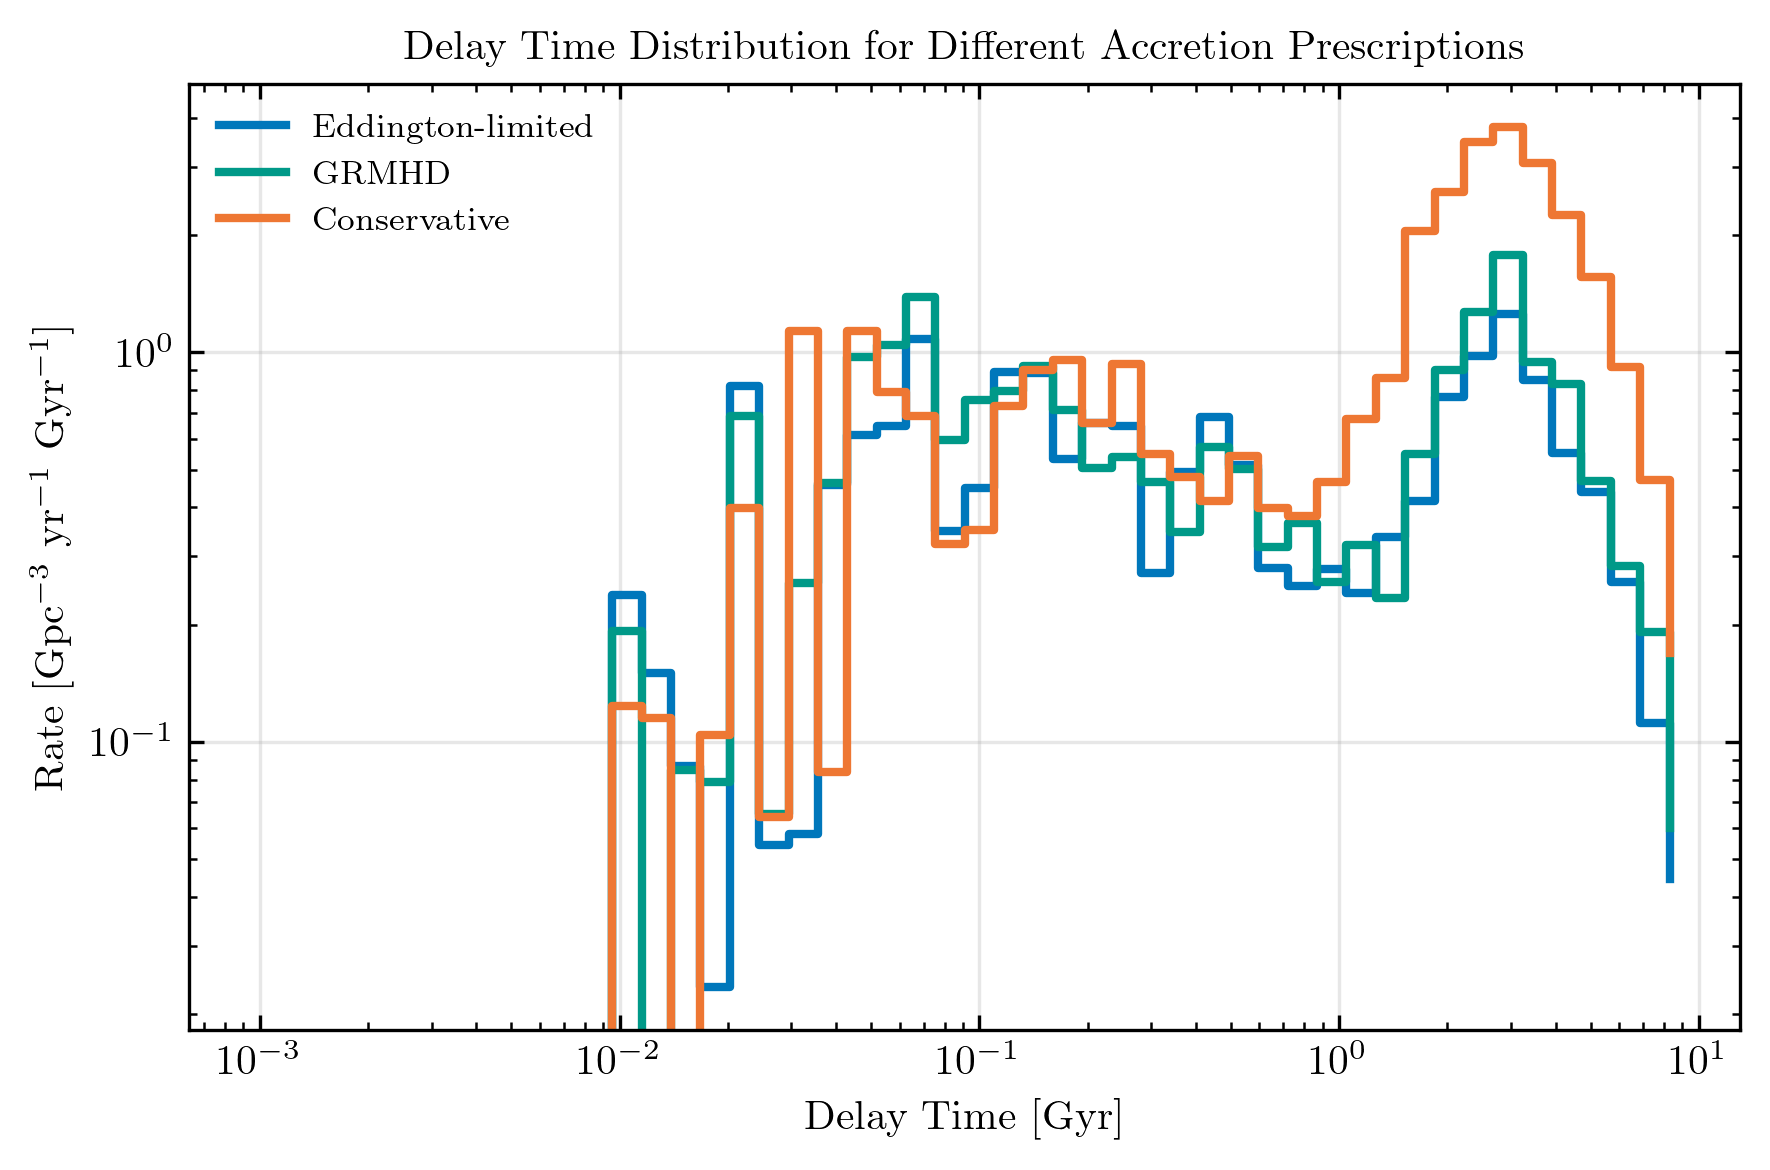

In [6]:
# Load data for the three accretion populations
data_dir = '/home/users/b/briel/scratch/high_mass_physics/data/main_figure/'
folder_types = ['Eddington-limited', 'GRMHD', 'conservative']
labels = ['Eddington-limited', 'GRMHD', 'Conservative']
colors = [tol_vibrant[0], tol_vibrant[2], tol_vibrant[3]]

# Create figure
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

# Define delay time bins (in Gyr)
delay_bins = np.logspace(-3, 1, 50)  # From 1 Myr to 10 Gyr

for i, (folder_type, label, color) in enumerate(zip(folder_types, labels, colors)):
    print(f"Processing folder: {folder_type}")
    co_contact_file = os.path.join(data_dir, folder_type + '.h5')
    data = Rates(co_contact_file, 'BBH', 'IllustrisTNG')
    
    # Get delay time (time to merger from ZAMS)
    delay_time = data.population['time'].to_numpy()  # in Myr
    
    # Apply mass cut (max mass > 40 M_sun)
    max_mass = np.maximum(data.population['S1_mass'].values, 
                         data.population['S2_mass'].values)
    mass_mask = max_mass > 40.0
    
    # Apply redshift cut
    z_max = 2
    z_mask = data.z_events <= z_max
    volume = get_shell_comoving_volume(0, z_max)
    
    # Get weights for systems that pass cuts
    weights = np.sum(data.weights[z_mask], axis=1)[mass_mask]
    delay_time_filtered = delay_time[mass_mask] / 1000  # Convert to Gyr
    
    # Create histogram
    h, _ = np.histogram(delay_time_filtered, bins=delay_bins, weights=weights)
    
    # Normalize by bin width to get rate per Gyr
    bin_widths = np.diff(delay_bins)
    rates = h / bin_widths / volume
    
    # Plot
    ax.step(delay_bins[:-1], rates, where='post', label=label, color=color, lw=2)
    
    print(f"  Total systems: {np.sum(mass_mask)}")
    print(f"  Total rate: {np.sum(weights)/volume:.2e} yr^-1")

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Delay Time [Gyr]')
ax.set_ylabel(r'Rate [Gpc$^{-3}$ yr$^{-1}$ Gyr$^{-1}$]')
ax.set_title('Delay Time Distribution for Different Accretion Prescriptions')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
# Load the three different grids for different accretion efficiencies

# grid locations
grids_path = '/srv/astro/projects/posydon/max/population_synthesis/250825_high_mass/grid_links'

grid_types = ['eddington_limited', 'GRMHD', 'conservative']



import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import cmap
import warnings
from posydon.popsyn.synthetic_population import Population, Rates
from posydon.grids.psygrid import PSyGrid
from posydon.utils.common_functions import convert_metallicity_to_string
from posydon.config import PATH_TO_POSYDON_DATA, PATH_TO_POSYDON
from posydon.utils.common_functions import inspiral_timescale_from_separation
from matplotlib.lines import Line2D

# Suppress warnings about missing ini parameters
warnings.filterwarnings('ignore', message='Missing ini parameter:.*')

# Constants
METALLICITY = 0.1
DPI = 300
DONOR_MASS = 33.8767  # Fixed donor mass in solar masses
HUBBLE_TIME = 13.8e9  # years
MARKER_SIZE = 9
MASS_TOLERANCE = 2.0  # solar masses
CO_TYPE = 'BBH'
SFH_IDENTIFIER = "IllustrisTNG"

inspiral_timescale_from_separation = np.vectorize(inspiral_timescale_from_separation)

plt.style.use(str(Path(PATH_TO_POSYDON) / 'posydon' / 'visualization' / 'posydon.mplstyle'))

# Color schemes
tol_vibrant = cmap.Colormap('tol:vibrant')(np.linspace(0, 1, 7))

def plot_donor_mass_analysis(M_donor, ax, grid, m1_initial, metallicity, hist2d_colour, marker_colours):
    """
    Plot analysis for a specific donor mass on the given axis.
    
    Parameters:
    -----------
    M_donor : float
        Donor mass in solar masses
    ax : matplotlib.axes.Axes
        Axis to plot on
    grid : PSyGrid
        Grid object containing stellar evolution data
    m1_initial : array
        Initial masses of primary stars
    metallicity : float
        Metallicity value
    hist2d_colour : colormap
        Colormap for 2D histogram
    marker_colours : array
        Color array for plotting
    """
    # Find the closest donor mass in the grid
    unique_masses = np.unique(m1_initial)
    closest_mass = unique_masses[np.argmin(np.abs(unique_masses - M_donor))]
    donor_mass_mask = m1_initial == closest_mass
    
    print(f"    Using donor mass: {closest_mass:.4f} M☉ (requested: {M_donor:.1f} M☉)")
    
    smt_mask = (grid.final_values['termination_flag_1'] == 'Primary has depleted central carbon')
    unstable_mask_rate = ((grid.final_values['termination_flag_1'] == 'Reached maximum mass transfer rate: 1d-1')
                    | (grid.final_values['termination_flag_1'] == 'Reached maximum mass transfer rate: Exceeded photon trapping radius'))
    unstable_mask_L2 = ((grid.final_values['termination_flag_1'] == 'overflow from L2 (D_L2) distance for q(=Macc/Mdon)>1, donor is star 1')
                        | (grid.final_values['termination_flag_1'] == 'overflow from L2 (R_L2) surface for q(=Macc/Mdon)<1, donor is star 1')
                        | (grid.final_values['termination_flag_1'] == 'overflow from L2 (R_L2) surface for q(=Macc/Mdon)>1, donor is star 1'))

    # Calculate x and y axes
    x_axis = grid.initial_values['star_2_mass']/grid.initial_values['star_1_mass']
    y_axis = np.log10(grid.initial_values['period_days'])
    
    # Plot unstable mass transfer cases
    ax.scatter(x_axis[donor_mass_mask & unstable_mask_rate],
               y_axis[donor_mass_mask & unstable_mask_rate],
               color='none',
               s=MARKER_SIZE-1,
               lw=0.9,
               edgecolor=marker_colours["Mdot"],
               marker='D', label='$\dot{M}_\mathrm{max}$',
               zorder=10)
    
    ax.scatter(x_axis[donor_mass_mask & unstable_mask_L2],
               y_axis[donor_mass_mask & unstable_mask_L2],
               color='none',
               s=MARKER_SIZE-1,
               lw=0.9,
               edgecolor=marker_colours["L2_overflow"],
               marker='D', label='$L_2$ overflow',
               zorder=10)
    
    # Plot SMT systems with merger analysis
    S1_mass_f = grid.final_values['S1_SN_MODEL_v2_01_mass'][donor_mass_mask & smt_mask]
    S2_mass_f = grid.final_values['star_2_mass'][donor_mass_mask & smt_mask]
    separation_f = grid.final_values['binary_separation'][donor_mass_mask & smt_mask]
    
    if len(S1_mass_f) != 0:
        
        PISN_mask = S1_mass_f == 0
        if np.any(PISN_mask):
            ax.scatter(x_axis[donor_mass_mask & smt_mask][PISN_mask],
                        y_axis[donor_mass_mask & smt_mask][PISN_mask],
                        color='red',
                        marker='*',
                        s=10,
                        label='PISN',
                        edgecolors='none')
            S1_mass_f = S1_mass_f[~PISN_mask]
            S2_mass_f = S2_mass_f[~PISN_mask]
            separation_f = separation_f[~PISN_mask]
    
        merger_times = inspiral_timescale_from_separation(S1_mass_f, S2_mass_f, separation_f, np.zeros(len(S1_mass_f)))
        no_merge = merger_times * 1e6 > HUBBLE_TIME
        
        # Create combined mask for non-PISN systems
        x_smt = x_axis[donor_mass_mask & smt_mask][~PISN_mask]
        y_smt = y_axis[donor_mass_mask & smt_mask][~PISN_mask]

        ax.scatter(x_smt[no_merge],
                   y_smt[no_merge],
                   color='none', marker='s',
                   s=MARKER_SIZE+1,
                   label='SMT ($t_\mathrm{merge} > t_\mathrm{Hubble}$)',
                   lw=1,
                   edgecolor=marker_colours["SMT_no_merge"],
                   zorder=10)
        ax.scatter(x_smt[~no_merge],
                   y_smt[~no_merge],
                   s=MARKER_SIZE+1,
                   color='none', marker='s', label='SMT ($t_\mathrm{merge} \leq t_\mathrm{Hubble}$)',
                   lw=1,
                   edgecolor=marker_colours["SMT_merger"], zorder=10)

    # Set plot properties
    ax.set_xscale('log')
    ax.set_xlim(0.05, 4)
    ax.set_ylim(-0.5, 3.5)
    
    return ax


def load_grid_data(path, metallicity):
    """
    Load the CO-HMS RLO grid data.
    
    Parameters
    ----------
    path : str or Path
        Path to the grid directory.
    metallicity : float
        Metallicity value.
        
    Returns
    -------
    tuple
        grid, m1_initial, m2_initial, p_initial
    """
    print("  Loading CO-HMS RLO grid...")
    str_met = convert_metallicity_to_string(metallicity)
    CO_HMS_RLO_file = Path(path) / 'CO-HMS_RLO' / f'{str_met}_Zsun.h5'
    grid = PSyGrid(str(CO_HMS_RLO_file))
    print(f"    ✓ Loaded grid from {Path(path).name}")
    
    print("  Parsing initial conditions from grid...")
    m1_initial = np.zeros(len(grid.MESA_dirs))
    p_initial = np.zeros(len(grid.MESA_dirs))
    m2_initial = np.zeros(len(grid.MESA_dirs))  

    for j, i in enumerate(grid.MESA_dirs):
        m2_initial[j] = float(str(i).split('_m2_')[1].split('_')[0])
        m1_initial[j] = float(str(i).split('_m1_')[1].split('_')[0])
        p_initial[j] = float(str(i).split('_days_')[1].split('_')[0])
    print(f"    ✓ Parsed initial conditions")
    
    return grid, m1_initial, m2_initial, p_initial


def create_figure(donor_mass, grid_paths, grid_labels, metallicity, output_folder):
    """
    Create and save the donor mass analysis figure for different accretion grids.
    
    Parameters
    ----------
    donor_mass : float
        Donor mass to analyze.
    grid_paths : list of str
        List of paths to the grid directories.
    grid_labels : list of str
        Labels for each grid.
    metallicity : float
        Metallicity value.
    output_folder : Path
        Output directory for the figure.
    """

    print(f"\nAnalyzing donor mass: {donor_mass} M☉ across {len(grid_paths)} grids")
    
    # Set up colormaps
    hist2d_colour = cmap.Colormap('crameri:grayc').to_mpl()
    marker_colours = {
        "SMT_no_merge": tol_vibrant[0],
        "SMT_merger": tol_vibrant[1],
        "Mdot": tol_vibrant[4],
        "L2_overflow": tol_vibrant[3]
    }

    fig, axes = plt.subplots(1, 3, figsize=(3.38*2, 2.535*0.7))
    plt.subplots_adjust(wspace=0.03, hspace=0.1)
    
    print("  Plotting grid analysis...")
    for grid_path, grid_label, ax in zip(grid_paths, grid_labels, axes):
        print(f"\n  Processing grid: {grid_label}")
        grid, m1_initial, m2_initial, p_initial = load_grid_data(grid_path, metallicity)
        ax = plot_donor_mass_analysis(donor_mass, ax, grid, m1_initial, metallicity, hist2d_colour, marker_colours)
        ax.set_title(grid_label)
        ax.set_xlabel('$M_\mathrm{acc}/M_\mathrm{donor}$')

    axes[0].set_ylabel('$\log_{10} P$ [days]')
    axes[1].set_yticklabels([])
    
    axes[-1].yaxis.set_ticks_position('right')
    axes[-1].set_ylabel('$\log_{10} P$ [days]')
    axes[-1].yaxis.set_label_position('right')
    axes[-1].tick_params(axis='y', which='both', left=True, right=True)

    # Save figure
    str_met = convert_metallicity_to_string(metallicity)
    
    # Create subdirectories for png and pdf
    png_folder = output_folder / 'png'
    pdf_folder = output_folder / 'pdf'
    png_folder.mkdir(parents=True, exist_ok=True)
    pdf_folder.mkdir(parents=True, exist_ok=True)
    
    output_file_png = png_folder / f'COHMS_RLO_accretion_comparison_M{int(donor_mass)}.png'
    output_file_pdf = pdf_folder / f'COHMS_RLO_accretion_comparison_M{int(donor_mass)}.pdf'
        
    # Get handles and labels from the first plot
    handles, labels = axes[0].get_legend_handles_labels()

    axes[1].legend(handles, labels, bbox_to_anchor=(0.5, -0.23), loc='upper center', ncol=3, frameon=False)
    
    print(f"\n  Saving figure to: {output_file_png}")
    plt.savefig(output_file_png, bbox_inches='tight', dpi=DPI)
    plt.savefig(output_file_pdf, bbox_inches='tight', dpi=DPI)
    plt.close(fig)
    print(f"  ✓ Figure saved successfully!")


# Main execution
print("\n" + "="*70)
print("CO-HMS Grid Slice Analysis - Accretion Efficiency Comparison")
print("="*70)

# Set up grid paths for different accretion efficiencies
grid_paths = [Path(grids_path) / grid_type  / 'POSYDON_data' for grid_type in grid_types]
grid_labels = ['Eddington-limited', 'GRMHD', 'Conservative']

output_folder = Path('/home/users/b/briel/scratch/high_mass_physics/figures')

print(f"\nMetallicity: {METALLICITY}")
print(f"Donor mass: {DONOR_MASS} M☉")
print(f"Accretion grids: {grid_types}")

# Load grid data and create figure
print("\n" + "-"*70)
print("Generating figure...")
print("-"*70)
create_figure(DONOR_MASS, grid_paths, grid_labels, METALLICITY, output_folder)

print("\n" + "="*70)
print("✓ Analysis complete!")
print("="*70 + "\n")



CO-HMS Grid Slice Analysis - Accretion Efficiency Comparison

Metallicity: 0.1
Donor mass: 33.8767 M☉
Accretion grids: ['eddington_limited', 'GRMHD', 'conservative']

----------------------------------------------------------------------
Generating figure...
----------------------------------------------------------------------

Analyzing donor mass: 33.8767 M☉ across 3 grids
  Plotting grid analysis...

  Processing grid: Eddington-limited
  Loading CO-HMS RLO grid...
    ✓ Loaded grid from POSYDON_data
  Parsing initial conditions from grid...
    ✓ Parsed initial conditions
    Using donor mass: 33.8767 M☉ (requested: 33.9 M☉)

  Processing grid: GRMHD
  Loading CO-HMS RLO grid...
    ✓ Loaded grid from POSYDON_data
  Parsing initial conditions from grid...
    ✓ Parsed initial conditions
    Using donor mass: 33.8767 M☉ (requested: 33.9 M☉)

  Processing grid: Conservative
  Loading CO-HMS RLO grid...
    ✓ Loaded grid from POSYDON_data
  Parsing initial conditions from grid...
  

In [1]:
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator,LogLocator,NullFormatter)
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt

In [23]:
import numpy as np
import pandas as pd
import h5py

data_file = "/home/users/b/briel/scratch/high_mass_physics/data/hm_dists.h5"


with h5py.File(data_file, "r") as hf:
    print(list(hf['1D'].keys()))

['chi_eff', 'mass1', 'mass_ratio', 'p_chi_eff', 'p_mass1', 'p_mass_ratio']


Text(0.5, 1.0, '$m_1>44M_{\\odot}$')

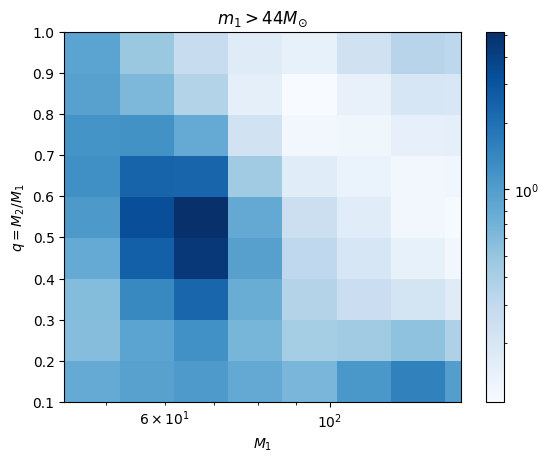

In [2]:
import numpy as np
import pandas as pd
import h5py

data_file = "/home/users/b/briel/scratch/high_mass_physics/data/hm_dists.h5"


with h5py.File(data_file, "r") as hf:
    matrix1 = hf["2D"]["p_m1q"][()]
    mbins = hf["2D"]["mass1"][()]
    qbins = hf["2D"]["mass_ratio"][()]
    
    matrix_m1chi = hf["2D"]["p_m1chi"][()]
    mbins = hf["2D"]["mass1"][()]
    chibins = hf["2D"]["chi_eff"][()]
    
fig,axes = plt.subplots(1,1,)
ax = axes
pc = ax.pcolor(mbins,qbins,matrix1.T,norm=LogNorm(vmin=matrix1[matrix1!=0].min(),vmax=matrix1.max()),cmap='Blues')
ax.set_xlabel(r'$M_{1}$')
ax.set_xlim(44, 150)
ax.set_ylabel(r'$q = M_2/M_1$')
ax.set_xscale("log")
cbar = fig.colorbar(pc, ax = ax)
plt.title('$m_1>44M_{\odot}$')

In [3]:
mbins

array([  5.        ,   5.91276901,   6.99216747,   8.26861423,
         9.77808119,  11.56310709,  13.67399625,  16.17023626,
        19.12217436,  22.61299999,  26.74108912,  31.6227766 ,
        37.3956347 ,  44.22234999,  52.29530811,  61.84201543,
        73.13151047,  86.48194574, 102.26955374, 120.9392496 ,
       143.01716942, 169.12549744, 200.        ])

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import os
import h5py
from cmap import Colormap
from scipy.interpolate import RegularGridInterpolator
from posydon.popsyn.synthetic_population import Rates
from posydon.popsyn.rate_calculation import get_shell_comoving_volume
from pathlib import Path
from posydon.config import PATH_TO_POSYDON


data_dir = '/home/users/b/briel/scratch/high_mass_physics/data/main_figure/'
folder_types = ['Eddington-limited', 'GRMHD', 'conservative']
SFH_type = 'IllustrisTNG'

cm_blues = Colormap('colorbrewer:Blues')
pdf_colours = cm_blues([0.2, 0.6, 1.0])
cm_grays = Colormap('colorbrewer:Greys')

In [19]:
cm = Colormap('tol:YlOrBr')

Processing folder: Eddington-limited
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max
Rates data loaded.
Processing folder: GRMHD
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max
Rates data loaded.
Processing folder: conservative
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max
Rates data loaded.


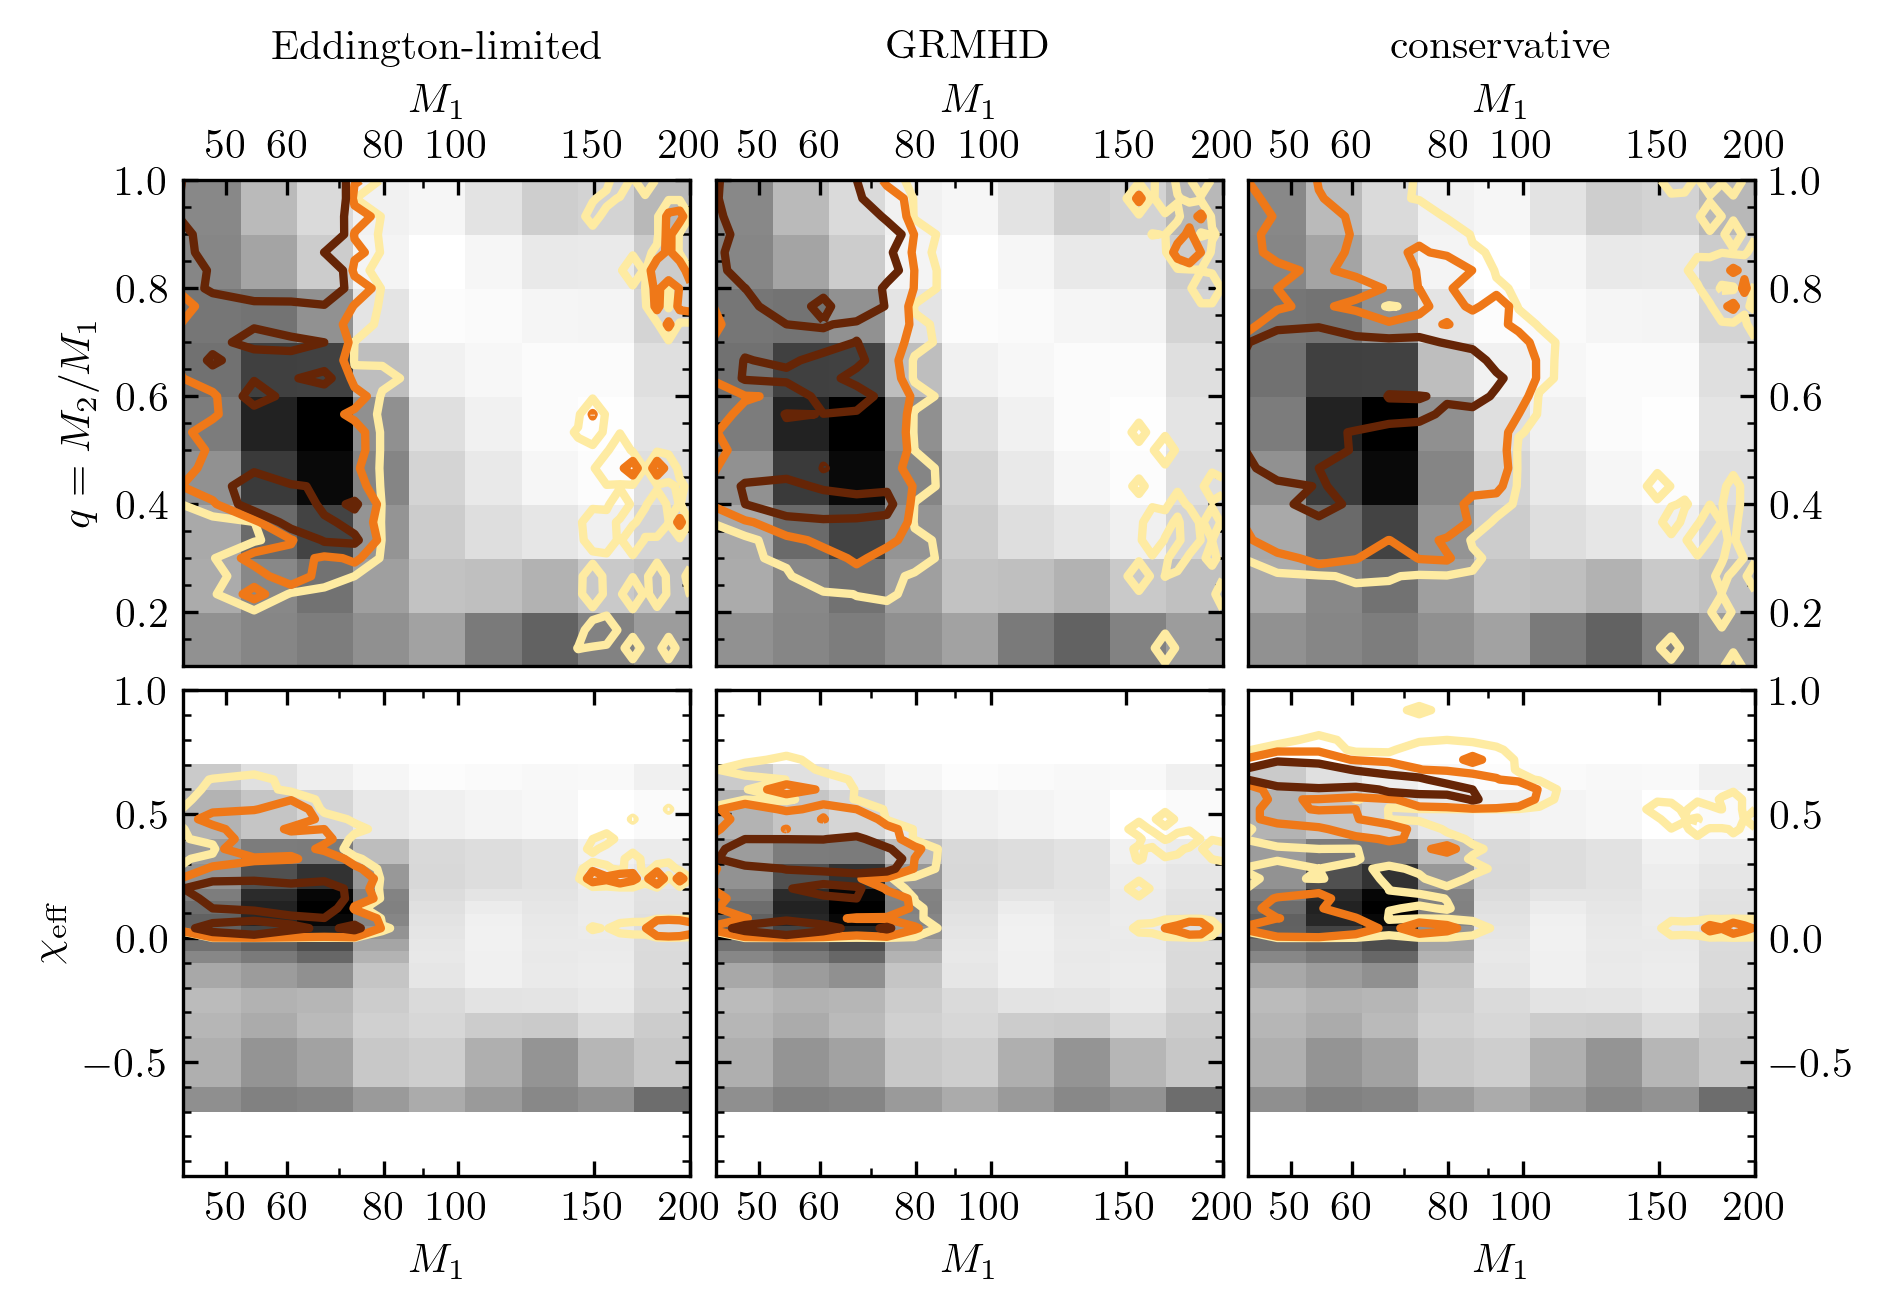

In [ ]:
mass_bins = np.linspace(10, 200, 31)
q_bins = np.linspace(0, 1, 31)
chi_bins = np.linspace(-1, 1, 51)



fig, axes = plt.subplots(2, 3, figsize=(3.38*2, 2.535*1.7))
plt.subplots_adjust(wspace=0.05, hspace=0.05)


for i, folder_type in enumerate(folder_types):
    print(f"Processing folder: {folder_type}")
    co_contact_file = os.path.join(data_dir, folder_type+'.h5',)
    #co_contact_file = os.path.join(folder_path, 'CO_contact.h5')
    data = Rates(co_contact_file, 'BBH', SFH_type)
    print("Rates data loaded.")
    max_mass = np.maximum(data.population['S1_mass'].values, data.population['S2_mass'].values)
    mask = max_mass > 44.2
    z_max = 2
    z_event_mask = data.z_events <= z_max
    volume = get_shell_comoving_volume(0, z_max)
    weights = data.weights[z_event_mask][mask]
    filtered_population = data.population[mask]
    M1_mass = np.max(filtered_population[['S1_mass', 'S2_mass']], axis=1).to_numpy()
    mass_ratio = filtered_population['mass_ratio'].to_numpy()
    chi_eff = filtered_population['chi_eff'].to_numpy()
    
    # Top row: chirp mass vs mass ratio
    H0, xedges0, yedges0 = np.histogram2d(M1_mass,
                                          mass_ratio,
                                          bins=(mass_bins, q_bins),
                                          weights=np.nansum(weights, axis=1)/volume)
    
    H0 /= (np.diff(mass_bins)[:, None] * np.diff(q_bins))
    H0_sorted = np.sort(H0.flatten())[::-1]
    H0_cumsum = H0_sorted.cumsum()
    H0_total = H0_cumsum[-1]
    # Find contour levels for 1, 2, 3 sigma (containing 68.3%, 95.4%, 99.7% of the total)
    level0_1 = H0_sorted[np.searchsorted(H0_cumsum, 0.683 * H0_total)]
    level0_2 = H0_sorted[np.searchsorted(H0_cumsum, 0.954 * H0_total)]
    level0_3 = H0_sorted[np.searchsorted(H0_cumsum, 0.997 * H0_total)]
    levels0 = [level0_3, level0_2, level0_1]

    #axes[0, i].imshow(H0.T,
                    #   origin='lower',
                    #   extent=[xedges0[0], xedges0[-1], yedges0[0], yedges0[-1]],
                    #   cmap=cm_grays.to_mpl(),
                    #   aspect='auto',
                    #   interpolation='bilinear')
    
    # Use bin edges directly with the histogram data
    # mbins and qbins are already the edges from histogram2d
    axes[0, i].contour(mass_bins[1:], q_bins[1:], H0.T,
                       levels=levels0,
                       colors=cm([0.2, 0.6, 1.0]),
                       linewidths=[2.0, 2.0, 2.0])

    axes[0, i].pcolor(mbins, qbins, matrix1.T, norm=LogNorm(vmin=matrix1[matrix1!=0].min(), vmax=matrix1.max()), cmap=cm_grays.to_mpl())


    # Top bottom row: Chirp mass vs chi_eff
    H1, xedges1, yedges1 = np.histogram2d(M1_mass,
                                            chi_eff,
                                            bins=(mass_bins, chi_bins),
                                            weights=np.nansum(weights, axis=1)/volume)
    H1 /= (np.diff(mass_bins)[:, None] * np.diff(chi_bins))
    H1_sorted = np.sort(H1.flatten())[::-1]
    H1_cumsum = H1_sorted.cumsum()
    H1_total = H1_cumsum[-1]
    # Find contour levels for 1, 2, 3 sigma (containing 68.3%, 95.4%, 99.7% of the total)
    level1_1 = H1_sorted[np.searchsorted(H1_cumsum, 0.683 * H1_total)]
    level1_2 = H1_sorted[np.searchsorted(H1_cumsum, 0.954 * H1_total)]
    level1_3 = H1_sorted[np.searchsorted(H1_cumsum, 0.997 * H1_total)]
    levels1 = [level1_3, level1_2, level1_1]
    
    axes[1, i].contour(mass_bins[1:], chi_bins[1:], H1.T,
                       levels=levels1,
                       colors=cm([0.2, 0.6, 1.0]),
                       linewidths=[2.0, 2.0, 2.0])

    axes[1, i].pcolor(mbins,
                      chibins,
                      matrix_m1chi.T,
                      norm=LogNorm(vmin=matrix_m1chi[matrix_m1chi!=0].min(),vmax=matrix_m1chi[matrix_m1chi!=0].max()),cmap=cm_grays.to_mpl())

    axes[0, i].set_title(folder_type)
    
# axes and stuff
for ax in axes.flatten():
    ax.set_xscale('log')
    ax.set_xlim(44, 200)
    ax.xaxis.set_ticks([50, 60, 80, 100, 150, 200])
    ax.set_xticklabels([])

# Top row: x-axis at top
for ax in axes[0, :]:
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    ax.set_xlabel(r'$M_{1}$')
    ax.xaxis.set_ticks([50, 60, 80, 100, 150, 200])
    ax.set_xticklabels([50, 60, 80, 100, 150, 200])
    ax.set_ylim(0.1, 1)


# Bottom row: x-axis at bottom
for ax in axes[1, :]:
    ax.set_xlabel(r'$M_{1}$')
    ax.xaxis.set_ticks([50, 60, 80, 100, 150, 200])
    ax.set_xticklabels([50, 60, 80, 100, 150, 200])

axes[0, 0].set_ylabel(r'$q = M_2/M_1$')
axes[1, 0].set_ylabel(r'$\chi_\mathrm{eff}$')

for ax in axes[:, 1]:
    ax.set_yticklabels([])

for ax in axes[:, 2]:
    ax.yaxis.tick_right()
    ax.yaxis.set_label_position('right')
    

    
# for ax in axes[0,:]:
#     ax.xaxis.set_label_position('top')
#     ax.xaxis.tick_top()
#     ax.xaxis.set_ticks_position('both')
#     ax.set_ylim(1e-2,1)
#     ax.set_title(folder_types[axes[0,:].tolist().index(ax)])